In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import math
import os
import time
import requests
import pandas as pd
import json
import numpy as np
from pathlib import Path
from typing import Optional, Dict, List, Union
from unidecode import unidecode
import matplotlib.pyplot as plt
import seaborn as sns

import pandas_gbq
from google.auth import default
from google.cloud import bigquery
from google.api_core.exceptions import NotFound

In [3]:
from funcoes_escoragem import *

In [4]:
BASE_DIR = Path("data")
RAW_DIR = BASE_DIR / "raw"
TRUSTED_DIR = BASE_DIR / "trusted"
ANALYTICS_DIR = BASE_DIR / "analytics"

for path in [RAW_DIR, TRUSTED_DIR, ANALYTICS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

## Base

In [ ]:
project_id = 'loft-dl-datascience'

query = '''
WITH
consulta_realizada as(
  SELECT t2.*
  FROM loft-dl-fintech.bronze_credpago_core.imovel_analise as t1
  LEFT JOIN loft-dl-fintech.bronze_credpago_sortinghat.consulta_realizada as t2
    on t1.id_consulta = t2.id_consulta
  where t1._sdc_deleted_at is null and
    REGEXP_CONTAINS(t2.id_externo, r'^[0-9]+$') and
    date(t2.data) >= date('2026-01-01')
),
pc_cidadade_maio2026 as(
  select * from loft-dl-datascience.ds_risk_cp.blend3_2__variavel_cidade
  where mes_referencia = date('2026-05-01')
),
pc_imob_maio2026 as(
  select * from loft-dl-datascience.ds_risk_cp.blend3_2__variavel_imobiliaria
  where mes_referencia = date('2026-05-01')
),
tb_leads as(
  SELECT
    rf.contract_id,
    date(cf.requested_at) as requested_at,
    cf.tipo,
    cf.tipo_contrato,
    cf.rule,
    cf.bureau_nm,
    cf.modeloBlend,
    rf.approved_products,
    case when '32' in unnest(json_value_array(rf.approved_products)) then 1 else 0 end as flag_pop32,
    rd.product_nm,
    case when cf.modeloBlend = 'BLEND_REGRESSAO_2026' and cf.bureau_nm in ('BLEND_REGRESSAO_2026', 'BVS_CUSTOM', 'HVA3') then 'BLEND2'
        when cf.modeloBlend in ('BLEND3_3', 'BLEND3_4') and cf.bureau_nm in ('BLEND3_3', 'BLEND3_4', 'BVS_CUSTOM', 'HVA4') then 'BLEND3'
        when cf.modeloBlend in ('BLEND_4', 'BVS_CUSTOM_V2', 'HFT1') and cf.bureau_nm in ('BLEND_4', 'BVS_CUSTOM_V2', 'HFT1') then 'BLEND4'
        else 'Outros' end as bureau_nm_ajust,
    case when cf.modeloBlend in ('BLEND3_3', 'BLEND3_4') and cf.bureau_nm in ('BVS_CUSTOM', 'HVA4') then 1
        when cf.bureau_nm in ('BVS_CUSTOM_V2', 'HFT1') then 1
        else 0 end as is_fallback, -- apenas blend3 e blend4
    i.id_imobiliaria,
    i.id_cidade_ibge,
    i.cidade as imovel_cidade,
    i.uf as imovel_uf,
    ad.segmentacao as agency_segmentacao,
    rd.lead_elegivel,
    rd.proposta_iniciada,
    rd.proposta_enviada,
    rd.proposta_aprovada,
    rd.proposta_ativada,
    rd.is_activeted,
    rd.aprovado_motor_mesa,
    coalesce(cf.rating_score_ds, '-1') as rating_score_ds,
    case when coalesce(cf.qtd_proponentes, -1) <= 1 then 1 else 0 end as is_single_proponent,
    ca.blend_regressao_predict_nr,
    pc_cidade.city_pc4_mais_100_contratos__pc_categorias as city_pc4_mais_100_contratos__pc_categorias_maio2026,
    pc_imob.agency_pc4_mais_100_contratos__pc_categorias as agency_pc4_mais_100_contratos__pc_categorias_maio2026,
    cr.*,
    cast(JSON_EXTRACT(json_retornado, '$.blendRegressaoPredict') as float64) AS cr_blendRegressaoPredict
  from loft-dl-fintech.cp_gold.requests_fact as rf
  left join loft-dl-fintech.cp_gold.requests_dim AS rd
    on rf.contract_id = rd.contract_id
  left join loft-dl-fintech.cp_gold.credit_fact as cf
    on rf.contract_id = cf.contract_id
  left join loft-dl-fintech.cp_silver.int_credit_analyses as ca
    on rf.contract_id = ca.contract_id
  left join loft-dl-fintech.bronze_credpago_enriched.imovel as i
    on rf.contract_id = i.id
  left join loft-dl-fintech.cp_gold.agency_dim as ad
    on rd.agency_id = ad.agency_id
  left join consulta_realizada as cr
    on cast(rf.contract_id as FLOAT64) = cast(cr.id_externo as FLOAT64)
  left join pc_cidadade_maio2026 as pc_cidade
    on cast(i.id_cidade_ibge as float64) = cast(pc_cidade.id_cidade_ibge as float64)
  left join pc_imob_maio2026 as pc_imob
    on cast(i.id_imobiliaria as float64) = cast(pc_imob.agency_id as float64)
  where cf.tipo_contrato = 'PF' and
    date(cf.requested_at) >= date('2026-07-01') and
    date(cf.requested_at) < date(current_date())
)
select * from tb_leads
'''

In [ ]:
# df_model = pd.read_gbq(query, project_id=project_id)
# df_model

,contract_id,requested_at,tipo,tipo_contrato,rule,bureau_nm,modeloBlend,approved_products,flag_pop32,product_nm,...,_sdc_table_version,request,_sdc_received_at,_sdc_sequence,documento,rating,_sdc_batched_at,data,result,cr_blendRegressaoPredict
0,4322310,2026-07-02,PF,PF,BLEND_REGRESSAO_2026,BLEND_REGRESSAO_2026,BLEND_REGRESSAO_2026,[],0,None,...,1786647574343,"{""valor_aluguel"":3500,""matchmaking_on"":false,""...",2026-08-13 19:38:27+00:00,1786649903277863868,86447114900,C,2026-08-13 19:42:18.044000+00:00,2026-07-02 09:08:21+00:00,REPROVAR,0.0937
1,4324039,2026-07-02,PF,PF,BLEND_HVA3_BVS,HVA3,BLEND3_3,"[25,26,18,20,33,34,35,36,38,39]",0,None,...,1786647574343,"{""valor_aluguel"":2050,""matchmaking_on"":false,""...",2026-08-13 19:38:27+00:00,1786649903620829552,34393575890,A,2026-08-13 19:42:18.942000+00:00,2026-07-02 12:05:12+00:00,APROVAR,NaN
2,4323023,2026-07-02,PF,PF,BLEND_REGRESSAO_2026,BLEND_REGRESSAO_2026,BLEND_REGRESSAO_2026,"[25,26,18,20,33,34,35,36,38,40]",0,Flex,...,1786647574343,"{""valor_aluguel"":1650,""matchmaking_on"":false,""...",2026-08-13 19:38:27+00:00,1786649903398030855,04483937006,D,2026-08-13 19:42:18.419000+00:00,2026-07-02 10:23:40+00:00,APROVAR,0.2229
3,4326992,2026-07-02,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,"[25,26,18,20,33,34,35,36,38,41]",0,Smart Plus,...,1786647574343,"{""valor_aluguel"":5000,""matchmaking_on"":false,""...",2026-08-13 19:38:31+00:00,1786649907202943167,22048524818,C,2026-08-13 19:42:18.237000+00:00,2026-07-08 10:38:34+00:00,APROVAR,547.0000
4,4394604,2026-07-20,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,"[25,26,18,20,33,34,35,36,38]",0,None,...,1786647574343,"{""valor_aluguel"":1700,""matchmaking_on"":false,""...",2026-08-13 19:38:40+00:00,1786649914992635790,05916879920,D,2026-08-13 19:42:18.442000+00:00,2026-07-20 14:08:31+00:00,APROVAR,398.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201337,4441019,2026-07-30,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,[],0,None,...,1786647574343,"{""valor_aluguel"":3700,""matchmaking_on"":false,""...",2026-08-13 19:38:43+00:00,1786649921510136636,57899088100,E,2026-08-13 19:42:31.081000+00:00,2026-07-30 09:29:46+00:00,REPROVAR,326.0000
201338,4447958,2026-07-31,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,[],0,None,...,1786647574343,"{""valor_aluguel"":1800,""matchmaking_on"":false,""...",2026-08-13 19:38:47+00:00,1786649922477187125,03547294037,E,2026-08-13 19:42:21.403000+00:00,2026-07-31 11:37:57+00:00,REPROVAR,152.0000
201339,4512412,2026-08-14,PF,PF,BLEND3_4,BLEND3_4,BLEND3_4,[],0,None,...,1786647574343,"{""valor_aluguel"":1500,""matchmaking_on"":false,""...",2026-08-14 18:00:27+00:00,1786730422509989430,11542627230,E,2026-08-14 18:06:07.968000+00:00,2026-08-14 11:17:23+00:00,REPROVAR,NaN
201340,4492344,2026-08-11,PF,PF,BLEND_HVA3_BVS,HVA3,BLEND3_4,[],0,None,...,1786647574343,"{""valor_aluguel"":2125,""matchmaking_on"":false,""...",2026-08-13 19:38:51+00:00,1786649929019369548,09092321800,E,2026-08-13 19:42:36.263000+00:00,2026-08-11 08:36:25+00:00,REPROVAR,NaN


In [ ]:
# df_model.to_parquet(ANALYTICS_DIR / "df_model_simulacao_blend.parquet")

In [5]:
df_model = pd.read_parquet(ANALYTICS_DIR / "df_model_simulacao_blend.parquet")
df_model

,contract_id,requested_at,tipo,tipo_contrato,rule,bureau_nm,modeloBlend,approved_products,flag_pop32,product_nm,...,_sdc_table_version,request,_sdc_received_at,_sdc_sequence,documento,rating,_sdc_batched_at,data,result,cr_blendRegressaoPredict
0,4322310,2026-07-02,PF,PF,BLEND_REGRESSAO_2026,BLEND_REGRESSAO_2026,BLEND_REGRESSAO_2026,[],0,None,...,1786647574343,"{""valor_aluguel"":3500,""matchmaking_on"":false,""...",2026-08-13 19:38:27+00:00,1786649903277863868,86447114900,C,2026-08-13 19:42:18.044000+00:00,2026-07-02 09:08:21+00:00,REPROVAR,0.0937
1,4324039,2026-07-02,PF,PF,BLEND_HVA3_BVS,HVA3,BLEND3_3,"[25,26,18,20,33,34,35,36,38,39]",0,None,...,1786647574343,"{""valor_aluguel"":2050,""matchmaking_on"":false,""...",2026-08-13 19:38:27+00:00,1786649903620829552,34393575890,A,2026-08-13 19:42:18.942000+00:00,2026-07-02 12:05:12+00:00,APROVAR,NaN
2,4323023,2026-07-02,PF,PF,BLEND_REGRESSAO_2026,BLEND_REGRESSAO_2026,BLEND_REGRESSAO_2026,"[25,26,18,20,33,34,35,36,38,40]",0,Flex,...,1786647574343,"{""valor_aluguel"":1650,""matchmaking_on"":false,""...",2026-08-13 19:38:27+00:00,1786649903398030855,04483937006,D,2026-08-13 19:42:18.419000+00:00,2026-07-02 10:23:40+00:00,APROVAR,0.2229
3,4326992,2026-07-02,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,"[25,26,18,20,33,34,35,36,38,41]",0,Smart Plus,...,1786647574343,"{""valor_aluguel"":5000,""matchmaking_on"":false,""...",2026-08-13 19:38:31+00:00,1786649907202943167,22048524818,C,2026-08-13 19:42:18.237000+00:00,2026-07-08 10:38:34+00:00,APROVAR,547.0000
4,4394604,2026-07-20,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,"[25,26,18,20,33,34,35,36,38]",0,None,...,1786647574343,"{""valor_aluguel"":1700,""matchmaking_on"":false,""...",2026-08-13 19:38:40+00:00,1786649914992635790,05916879920,D,2026-08-13 19:42:18.442000+00:00,2026-07-20 14:08:31+00:00,APROVAR,398.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201337,4441019,2026-07-30,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,[],0,None,...,1786647574343,"{""valor_aluguel"":3700,""matchmaking_on"":false,""...",2026-08-13 19:38:43+00:00,1786649921510136636,57899088100,E,2026-08-13 19:42:31.081000+00:00,2026-07-30 09:29:46+00:00,REPROVAR,326.0000
201338,4447958,2026-07-31,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,[],0,None,...,1786647574343,"{""valor_aluguel"":1800,""matchmaking_on"":false,""...",2026-08-13 19:38:47+00:00,1786649922477187125,03547294037,E,2026-08-13 19:42:21.403000+00:00,2026-07-31 11:37:57+00:00,REPROVAR,152.0000
201339,4512412,2026-08-14,PF,PF,BLEND3_4,BLEND3_4,BLEND3_4,[],0,None,...,1786647574343,"{""valor_aluguel"":1500,""matchmaking_on"":false,""...",2026-08-14 18:00:27+00:00,1786730422509989430,11542627230,E,2026-08-14 18:06:07.968000+00:00,2026-08-14 11:17:23+00:00,REPROVAR,NaN
201340,4492344,2026-08-11,PF,PF,BLEND_HVA3_BVS,HVA3,BLEND3_4,[],0,None,...,1786647574343,"{""valor_aluguel"":2125,""matchmaking_on"":false,""...",2026-08-13 19:38:51+00:00,1786649929019369548,09092321800,E,2026-08-13 19:42:36.263000+00:00,2026-08-11 08:36:25+00:00,REPROVAR,NaN


In [11]:
df_model.groupby("bureau_nm_ajust", dropna=False).size()

bureau_nm_ajust
BLEND2      1485
BLEND3    141424
BLEND4     50439
Outros      7994
dtype: int64

In [13]:
df_model[["json_retornado", "request"]]

,json_retornado,request
0,"{""pessoas"":[{""nome"":""CARLOS VENICIO ASSI"",""doc...","{""valor_aluguel"":3500,""matchmaking_on"":false,""..."
1,"{""pessoas"":[{""nome"":""EVERSON DE OLIVEIRA DOS S...","{""valor_aluguel"":2050,""matchmaking_on"":false,""..."
2,"{""pessoas"":[{""nome"":""SAMUEL DOS SANTOS RIBEIRO...","{""valor_aluguel"":1650,""matchmaking_on"":false,""..."
3,"{""pessoas"":[{""nome"":""GILVAN FIGUEIRA DE SOUZA""...","{""valor_aluguel"":5000,""matchmaking_on"":false,""..."
4,"{""pessoas"":[{""nome"":""LUCIA DE LA CARIDAD CRUZ ...","{""valor_aluguel"":1700,""matchmaking_on"":false,""..."
...,...,...
201337,"{""pessoas"":[{""nome"":""HUMBERTO AUGUSTO ARMENIO ...","{""valor_aluguel"":3700,""matchmaking_on"":false,""..."
201338,"{""pessoas"":[{""nome"":""BRUNA KAROLYNA DOS SANTOS...","{""valor_aluguel"":1800,""matchmaking_on"":false,""..."
201339,"{""pessoas"":[{""nome"":"""",""documento"":""1154262723...","{""valor_aluguel"":1500,""matchmaking_on"":false,""..."
201340,"{""pessoas"":[{""nome"":""ANTONIO CARLOS JOSE VIEIR...","{""valor_aluguel"":2125,""matchmaking_on"":false,""..."


In [14]:
def unwrap_payload(obj):
    """Supports old format (message wrapper) and new format (root payload)."""
    if not obj:
        return None
    if isinstance(obj, dict) and "message" in obj:
        return obj["message"]
    return obj


def get_pessoas(obj):
    payload = unwrap_payload(obj)
    return (payload or {}).get("pessoas") or []


def parse_json_col(series):
    return series.apply(lambda x: json.loads(x) if pd.notna(x) and x else None)


# --- json_retornado ---
parsed = parse_json_col(df_model["json_retornado"])
valid_parsed = parsed.dropna()
payload_parsed = valid_parsed.apply(unwrap_payload)

contrato_df = pd.json_normalize(payload_parsed.tolist(), sep="_")
contrato_df.index = payload_parsed.index
contrato_df = contrato_df.add_prefix("message_")

# first person only (pessoas is a list)
pessoa_records = payload_parsed.apply(lambda x: (get_pessoas(x) or [{}])[0])
pessoa_df = pd.json_normalize(pessoa_records.tolist(), sep="_")
pessoa_df.index = payload_parsed.index
pessoa_df = pessoa_df.add_prefix("pessoa_")

# --- request ---
request_parsed = parse_json_col(df_model["request"])
request_valid = request_parsed.dropna()
request_df = pd.json_normalize(request_valid.tolist(), sep="_")
request_df.index = request_valid.index
request_df = request_df.add_prefix("request_")

# unify old (snake_case) and new (camelCase) request schemas
REQUEST_FIELD_ALIASES = {
    "request_valorAluguel": ["request_valor_aluguel"],
    "request_imobiliariaId": ["request_imobiliaria_id"],
    "request_idExterno": ["request_id_externo"],
    "request_imovelTipo": ["request_imovel_tipo"],
    "request_principalDocument": ["request_pessoa_principal_documento"],
}

for target, sources in REQUEST_FIELD_ALIASES.items():
    existing_sources = [c for c in sources if c in request_df.columns]
    if not existing_sources and target not in request_df.columns:
        continue
    if target not in request_df.columns:
        request_df[target] = pd.NA
    for source in existing_sources:
        if target == "request_valorAluguel":
            request_df[target] = request_df[target].combine_first(
                pd.to_numeric(request_df[source], errors="coerce")
            )
        else:
            request_df[target] = request_df[target].combine_first(request_df[source])
        request_df = request_df.drop(columns=[source])

# --- join back ---
df_expandido = (
    df_model
    .join(contrato_df, how="left")
    .join(pessoa_df, how="left")
    .join(request_df, how="left")
)

In [23]:
df_expandido[["request_imovelTipo", "message_blend3Variables_hasPreviousContracts", "message_blend3Variables_hadOverdueInvoiceInPreviousContracts"]]

,request_imovelTipo,message_blend3Variables_hasPreviousContracts,message_blend3Variables_hadOverdueInvoiceInPreviousContracts
0,RESIDENCIAL,NaN,NaN
1,RESIDENCIAL,NaN,NaN
2,RESIDENCIAL,NaN,NaN
3,RESIDENCIAL,False,False
4,RESIDENCIAL,False,False
...,...,...,...
201337,RESIDENCIAL,False,False
201338,RESIDENCIAL,False,False
201339,RESIDENCIAL,False,False
201340,RESIDENCIAL,NaN,NaN


In [25]:
df_expandido = df_expandido.replace({
    "request_imovelTipo": {"RESIDENCIAL": 1, "COMERCIAL": 0}, 
    "message_blend3Variables_hasPreviousContracts": {True: 1, False: 0},
    "message_blend3Variables_hadOverdueInvoiceInPreviousContracts": {True: 1, False: 0}
}
)

In [27]:
df_expandido.groupby("bureau_nm_ajust", dropna=False).size()

bureau_nm_ajust
BLEND2      1485
BLEND3    141424
BLEND4     50439
Outros      7994
dtype: int64

In [ ]:
df_expandido[df_expandido["bureau_nm_ajust"] == "BLEND2"][
    ["bureau_nm_ajust",
    "message_scores_BVS_CUSTOM_V2", "message_scores_HFT1", "pessoa_idade", "request_imovelTipo", 
    "message_qtdeRestricoesContrato", "request_valorAluguel", "message_rendaConsideradaContrato",
    "message_blend3Variables_realEstatePc4HistoryOver100Contracts", "message_blend3Variables_cityPc4HistoryOver100Contracts",
    "message_blend3Variables_hasPreviousContracts", "message_blend3Variables_hadOverdueInvoiceInPreviousContracts"
    ]
    ]

,bureau_nm_ajust,message_scores_BVS_CUSTOM_V2,message_scores_HFT1,pessoa_idade,request_imovelTipo,message_qtdeRestricoesContrato,request_valorAluguel,message_rendaConsideradaContrato,message_blend3Variables_realEstatePc4HistoryOver100Contracts,message_blend3Variables_cityPc4HistoryOver100Contracts,message_blend3Variables_hasPreviousContracts,message_blend3Variables_hadOverdueInvoiceInPreviousContracts
0,BLEND2,NaN,NaN,53.0,1.0,0.0,3500.00,10549.0,NaN,NaN,NaN,NaN
2,BLEND2,NaN,NaN,18.0,1.0,0.0,1650.00,1301.5,NaN,NaN,NaN,NaN
233,BLEND2,NaN,NaN,38.0,1.0,42.0,3410.00,4384.0,NaN,NaN,NaN,NaN
287,BLEND2,NaN,NaN,49.0,1.0,5.0,2500.00,5685.5,NaN,NaN,NaN,NaN
506,BLEND2,NaN,NaN,24.0,1.0,7.0,950.00,2329.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
200408,BLEND2,NaN,NaN,NaN,1.0,0.0,1100.00,0.0,NaN,NaN,NaN,NaN
200605,BLEND2,NaN,NaN,51.0,1.0,7.0,1000.00,4110.0,NaN,NaN,NaN,NaN
200606,BLEND2,NaN,NaN,26.0,1.0,2.0,1111.11,2671.5,NaN,NaN,NaN,NaN
200948,BLEND2,NaN,NaN,36.0,1.0,5.0,2100.00,3630.5,NaN,NaN,NaN,NaN


In [ ]:
df_expandido[df_expandido["bureau_nm_ajust"] == "BLEND3"][
    ["bureau_nm_ajust",
    "message_scores_BVS_CUSTOM", "message_scores_HVA4", "pessoa_idade", "request_imovelTipo", 
    "message_qtdeRestricoesContrato", "request_valorAluguel", "message_rendaConsideradaContrato",
    "message_blend3Variables_realEstatePc4HistoryOver100Contracts", "message_blend3Variables_cityPc4HistoryOver100Contracts",
    "message_blend3Variables_hasPreviousContracts", "message_blend3Variables_hadOverdueInvoiceInPreviousContracts"
    ]]

,bureau_nm_ajust,message_scores_BVS_CUSTOM,message_scores_HVA4,pessoa_idade,request_imovelTipo,message_qtdeRestricoesContrato,request_valorAluguel,message_rendaConsideradaContrato,message_blend3Variables_realEstatePc4HistoryOver100Contracts,message_blend3Variables_cityPc4HistoryOver100Contracts,message_blend3Variables_hasPreviousContracts,message_blend3Variables_hadOverdueInvoiceInPreviousContracts
3,BLEND3,699.0,583.0,45.0,1.0,0.0,5000.0,40072.5,NaN,0.119879,0.0,0.0
4,BLEND3,607.0,362.0,24.0,1.0,0.0,1700.0,1370.0,NaN,0.070133,0.0,0.0
5,BLEND3,653.0,707.0,28.0,1.0,0.0,1350.0,1507.0,NaN,0.057065,0.0,0.0
6,BLEND3,920.0,771.0,37.0,1.0,0.0,3500.0,6644.5,NaN,0.104675,0.0,0.0
7,BLEND3,338.0,NaN,NaN,1.0,0.0,2000.0,0.0,NaN,NaN,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
201335,BLEND3,510.0,280.0,26.0,1.0,5.0,1500.0,2055.0,NaN,0.075130,0.0,0.0
201336,BLEND3,385.0,NaN,NaN,1.0,0.0,1600.0,0.0,NaN,0.096525,0.0,0.0
201337,BLEND3,488.0,533.0,52.0,1.0,0.0,3700.0,4795.0,0.148936,0.093633,0.0,0.0
201338,BLEND3,479.0,209.0,33.0,1.0,9.0,1800.0,4795.0,0.123580,0.117021,0.0,0.0


In [34]:
df_expandido[df_expandido["bureau_nm_ajust"] == "BLEND4"][
    ["bureau_nm_ajust",
    "message_scores_BVS_CUSTOM_V2", "message_scores_HFT1", "pessoa_idade", "request_imovelTipo", 
    "message_qtdeRestricoesContrato", "request_valorAluguel", "message_rendaConsideradaContrato",
    "message_blend3Variables_realEstatePc4HistoryOver100Contracts", "message_blend3Variables_cityPc4HistoryOver100Contracts",
    "message_blend3Variables_hasPreviousContracts", "message_blend3Variables_hadOverdueInvoiceInPreviousContracts"
    ]]

,bureau_nm_ajust,message_scores_BVS_CUSTOM_V2,message_scores_HFT1,pessoa_idade,request_imovelTipo,message_qtdeRestricoesContrato,request_valorAluguel,message_rendaConsideradaContrato,message_blend3Variables_realEstatePc4HistoryOver100Contracts,message_blend3Variables_cityPc4HistoryOver100Contracts,message_blend3Variables_hasPreviousContracts,message_blend3Variables_hadOverdueInvoiceInPreviousContracts
13,BLEND4,486.0,389.0,21.0,1.0,0.0,3000.0,6850.0,NaN,0.091414,0.0,0.0
16,BLEND4,491.0,569.0,50.0,1.0,0.0,1600.0,2740.0,NaN,0.082314,0.0,0.0
19,BLEND4,704.0,536.0,60.0,1.0,1.0,6500.0,13152.0,NaN,0.066284,0.0,0.0
20,BLEND4,330.0,NaN,NaN,1.0,0.0,1200.0,0.0,NaN,NaN,0.0,0.0
23,BLEND4,479.0,507.0,45.0,1.0,0.0,1200.0,2671.5,NaN,0.082789,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
201320,BLEND4,683.0,766.0,44.0,0.0,0.0,1315.0,4384.0,0.045198,0.152513,0.0,0.0
201325,BLEND4,409.0,276.0,42.0,1.0,11.0,5000.0,2808.5,NaN,0.171472,0.0,0.0
201333,BLEND4,320.0,NaN,NaN,1.0,0.0,1500.0,0.0,NaN,NaN,0.0,0.0
201334,BLEND4,483.0,324.0,31.0,1.0,3.0,1500.0,1849.5,0.184466,0.111111,0.0,0.0


In [106]:
df_expandido[["city_pc4_mais_100_contratos__pc_categorias_maio2026", "agency_pc4_mais_100_contratos__pc_categorias_maio2026"]]

,city_pc4_mais_100_contratos__pc_categorias_maio2026,agency_pc4_mais_100_contratos__pc_categorias_maio2026
0,0.134769,0.302239
1,0.086642,NaN
2,0.144928,NaN
3,0.120974,NaN
4,0.068211,NaN
...,...,...
201337,0.112319,0.155556
201338,0.118619,0.103535
201339,NaN,NaN
201340,0.200637,NaN


## Alterações: Rodar

In [70]:
# df_expandido.to_csv(ANALYTICS_DIR / "df_model_simulacao_blend_expandido.csv")

In [519]:
df_expandido = pd.read_csv(ANALYTICS_DIR / "df_model_simulacao_blend_expandido.csv").drop(columns=["Unnamed: 0"])
df_expandido = df_expandido[df_expandido["is_fallback"] == 0]
df_expandido = df_expandido[df_expandido["is_single_proponent"] == 1]
df_expandido = df_expandido[df_expandido["bureau_nm_ajust"].isin(["BLEND3", "BLEND4"])]
df_expandido["safra"] = df_expandido["requested_at"].astype(str).str[:7]
df_expandido

,contract_id,requested_at,tipo,tipo_contrato,rule,bureau_nm,modeloBlend,approved_products,flag_pop32,product_nm,...,request_existingContractDebts_qtdeDividas,request_existingContractDebts_saldoReceber,request_existingContractDebts_taxaCredpago,request_scores_BVS_CUSTOM_V2,request_scores_HFT1,request_blend3Variables_hasPreviousContracts,request_blend3Variables_hadOverdueInvoiceInPreviousContracts,request_blend3Variables_cityPc4HistoryOver100Contracts,request_blend3Variables_realEstatePc4HistoryOver100Contracts,safra
3,4326992,2026-07-02,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,"[25,26,18,20,33,34,35,36,38,41]",0,Smart Plus,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-07
4,4394604,2026-07-20,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,"[25,26,18,20,33,34,35,36,38]",0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-07
5,4412815,2026-07-23,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,"[25,26,18,20,33,34,35,36,38]",0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-07
6,4413361,2026-07-23,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,"[25,26,18,20,33,34,35,36,38,39]",0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-07
7,4382728,2026-07-16,whatsapp,PF,BLEND3_3,BLEND3_3,BLEND3_3,[],0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201336,4467471,2026-08-05,PF,PF,BLEND3_4,BLEND3_4,BLEND3_4,[],0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-08
201337,4441019,2026-07-30,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,[],0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-07
201338,4447958,2026-07-31,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,[],0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-07
201339,4512412,2026-08-14,PF,PF,BLEND3_4,BLEND3_4,BLEND3_4,[],0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-08


In [520]:
RATING_GROUP_ORDER = {
    "A+": "A",
    "A": "A",
    "B+": "A",
    "B": "A",
    "C": "B",
    "D+": "C",
    "D": "D",
    "E": "E",
    "E-BVS": "E",
}

df_expandido["rating_score_ds_final"] = (
    df_expandido["rating_score_ds"].astype(str).replace({"-1": "N/I", "nan": "N/I"})
)

mask_blend4 = df_expandido["bureau_nm_ajust"] == "BLEND4"
df_expandido.loc[mask_blend4, "rating_score_ds_final"] = (
    df_expandido.loc[mask_blend4, "rating_score_ds"].replace(RATING_GROUP_ORDER)
)

df_expandido.groupby(["bureau_nm_ajust", "rating_score_ds_final"]).size()

bureau_nm_ajust  rating_score_ds_final
BLEND3           A                        15474
                 B                        27817
                 C                        31608
                 D                         1940
                 E                        62838
                 N/I                        212
BLEND4           A                        17764
                 B                         2611
                 C                         2711
                 D                         5867
                 E                        20445
dtype: int64

In [521]:
df_expandido.groupby(["bureau_nm_ajust", "rating_score_ds"], dropna=False).size()

bureau_nm_ajust  rating_score_ds
BLEND3           A                  15474
                 B                  27817
                 C                  31608
                 D                   1940
                 E                  62838
                 N/I                  212
BLEND4           A                   4918
                 A+                  2476
                 B                   5244
                 B+                  5126
                 C                   2611
                 D                   5867
                 D+                  2711
                 E                  14680
                 E-BVS               5765
dtype: int64

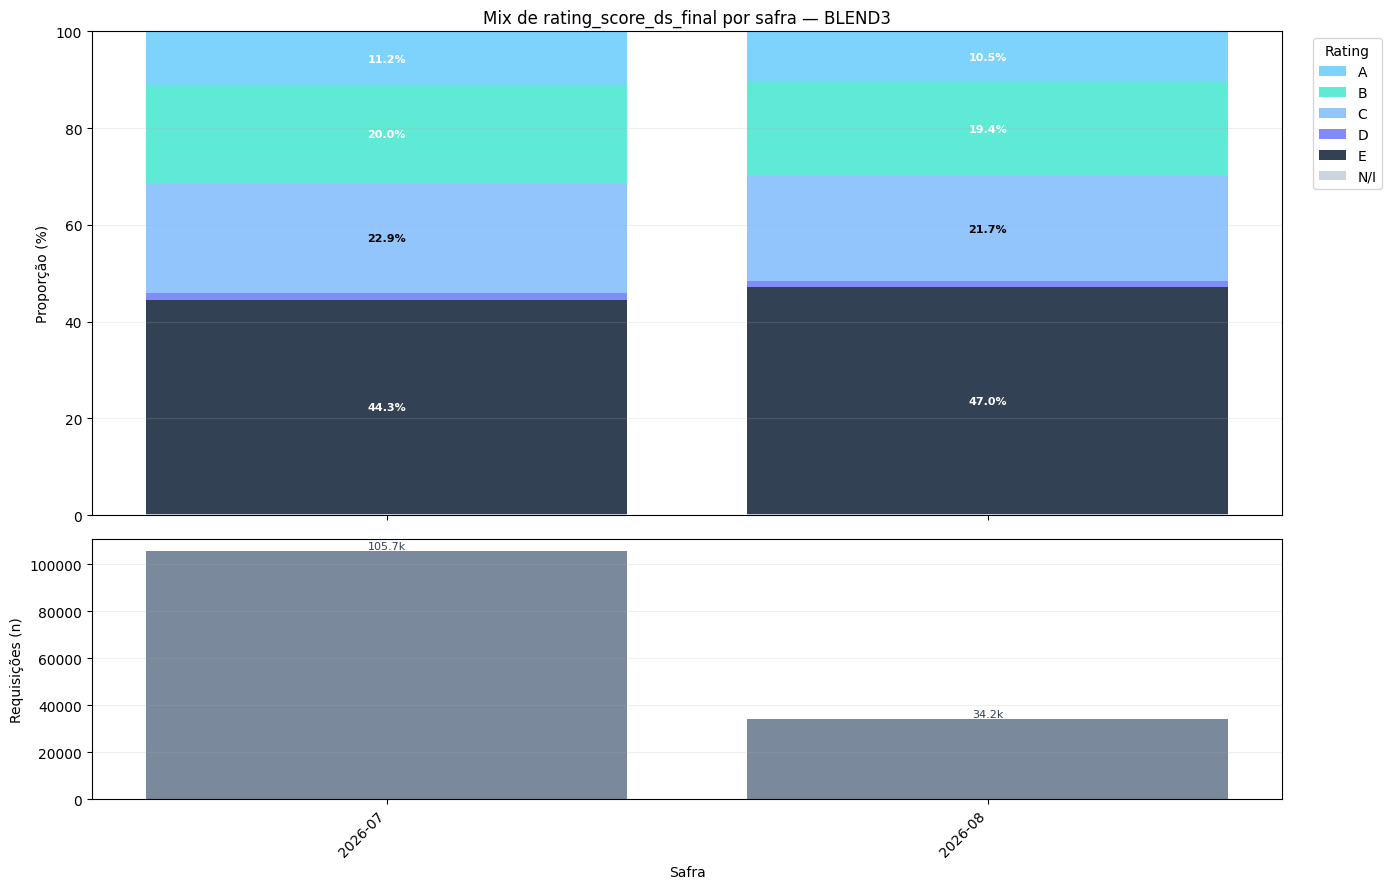

rating_score_ds_final,A,B,C,D,E,N/I,n
safra,,,,,,,
2026-07,11.2%,20.0%,22.9%,1.4%,44.3%,0.1%,"105,652"
2026-08,10.5%,19.4%,21.7%,1.2%,47.0%,0.2%,"34,237"


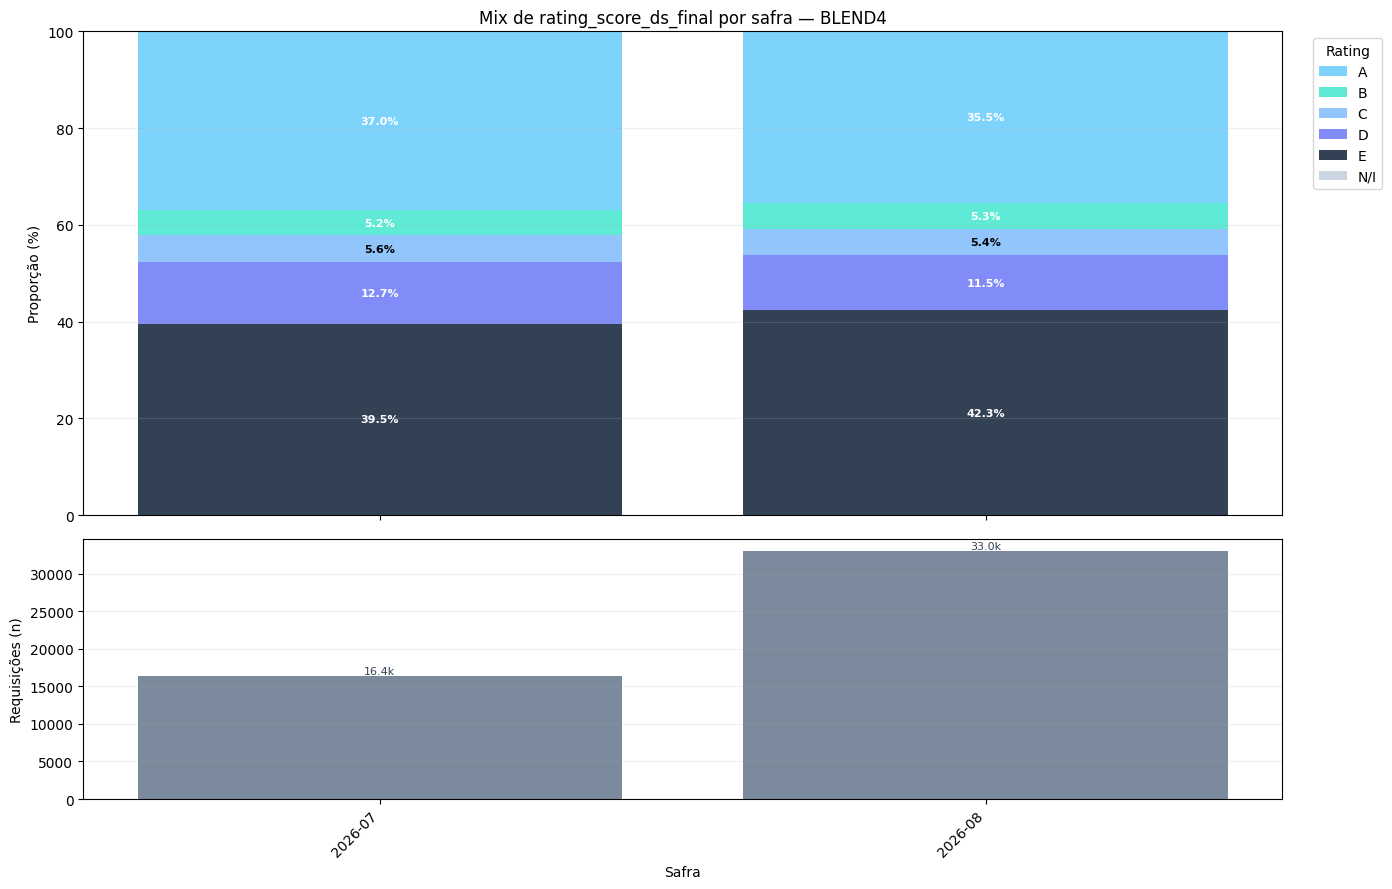

rating_score_ds_final,A,B,C,D,E,N/I,n
safra,,,,,,,
2026-07,37.0%,5.2%,5.6%,12.7%,39.5%,0.0%,"16,396"
2026-08,35.5%,5.3%,5.4%,11.5%,42.3%,0.0%,"33,002"


In [522]:
from funcoes_monitoramento import plot_mix_and_volume

RATING_ORDER = ["A", "B", "C", "D", "E", "N/I"]
RATING_COLOR_MAP = {
    "A": "#7DD3FC",
    "B": "#5EEAD4",
    "C": "#93C5FD",
    "D": "#818CF8",
    "E": "#334155",
    "N/I": "#CBD5E1",
}
RATING_TEXT_COLOR_MAP = {
    "A": "white", "B": "white", "C": "black",
    "D": "white", "E": "white", "N/I": "black",
}

plot_df = df_expandido.copy()
plot_df["requested_at"] = pd.to_datetime(plot_df["requested_at"])
plot_df["safra"] = plot_df["requested_at"].dt.strftime("%Y-%m")
plot_df["rating_score_ds_final"] = (
    plot_df["rating_score_ds_final"].astype(str).replace({"-1": "N/I", "nan": "N/I"})
)

safra_order = sorted(plot_df["safra"].dropna().unique())

for model in ["BLEND3", "BLEND4"]:
    sub = plot_df[plot_df["bureau_nm_ajust"] == model].dropna(subset=["safra", "rating_score_ds_final"])
    if sub.empty:
        print(f"[skip] {model}: sem dados")
        continue

    pct_df = (
        pd.crosstab(sub["safra"], sub["rating_score_ds_final"], normalize="index")
        .mul(100)
        .reindex(index=safra_order)
        .reindex(columns=RATING_ORDER, fill_value=0)
        .fillna(0)
    )
    volume = sub.groupby("safra").size().reindex(safra_order, fill_value=0)

    plot_mix_and_volume(
        pct_df,
        volume,
        title=f"Mix de rating_score_ds_final por safra — {model}",
        xlabel="Safra",
        category_order=RATING_ORDER,
        color_map=RATING_COLOR_MAP,
        text_color_map=RATING_TEXT_COLOR_MAP,
        reverse_stack=True,
        legend_title="Rating",
        min_label_pct=3.0,
    )
    plt.show()

    display(
        pct_df.round(1).assign(n=volume).style.format({**{c: "{:.1f}%" for c in RATING_ORDER}, "n": "{:,.0f}"})
        .set_caption(f"{model} — mix (%) e volume por safra")
    )

In [523]:
df_expandido.groupby("is_single_proponent", dropna=False).size()

is_single_proponent
1    189287
dtype: int64

In [524]:
df_expandido[df_expandido["is_fallback"] == 0].groupby(["bureau_nm_ajust", "bureau_nm"], dropna=False).size()

bureau_nm_ajust  bureau_nm
BLEND3           BLEND3_3     104682
                 BLEND3_4      35207
BLEND4           BLEND_4       49398
dtype: int64

In [525]:
df_expandido[df_expandido["is_single_proponent"] == 1].groupby(["bureau_nm_ajust", "bureau_nm"], dropna=False).size()

bureau_nm_ajust  bureau_nm
BLEND3           BLEND3_3     104682
                 BLEND3_4      35207
BLEND4           BLEND_4       49398
dtype: int64

In [526]:
df_expandido[df_expandido["is_single_proponent"] == 1].groupby(["bureau_nm_ajust", "modeloBlend"], dropna=False).size()


bureau_nm_ajust  modeloBlend
BLEND3           BLEND3_3       104682
                 BLEND3_4        35207
BLEND4           BLEND_4         49398
dtype: int64

In [527]:
df_expandido[df_expandido["is_single_proponent"] == 0].groupby(["bureau_nm_ajust", "modeloBlend"], dropna=False).size()

Series([], dtype: int64)

In [528]:
rename_dict_blend3 = {
    "message_scores_BVS_CUSTOM": "SCRCRDPNMGRLPFLGBCLFCREDPGV1",#
    "message_scores_HVA4": "SERASA_HVA4",
    "pessoa_idade": "age",
    "request_imovelTipo": "property_type",
    "message_qtdeRestricoesContrato": "qtde_restricoes__consulta_realizada",
    "request_valorAluguel": "rental_value",
    "message_rendaConsideradaContrato": "income",
    "message_blend3Variables_realEstatePc4HistoryOver100Contracts": "agency_pc4_mais_100_contratos__pc_categorias",
    "message_blend3Variables_cityPc4HistoryOver100Contracts": "city_pc4_mais_100_contratos__pc_categorias",
    # "agency_pc4_mais_100_contratos__pc_categorias_maio2026": "agency_pc4_mais_100_contratos__pc_categorias",
    # "city_pc4_mais_100_contratos__pc_categorias_maio2026": "city_pc4_mais_100_contratos__pc_categorias",
    "message_blend3Variables_hasPreviousContracts": "flag_tem__contratos_anteriores",
    "message_blend3Variables_hadOverdueInvoiceInPreviousContracts": "flag_teve_boleto_atrasado__contratos_anteriores",
}

In [529]:
rename_dict_blend4 = {
    "message_scores_BVS_CUSTOM_V2": "score_proposto__bvs",#
    "message_scores_HFT1": "SERASA_CHSV5",
    "pessoa_idade": "age",
    "request_imovelTipo": "property_type",
    "message_qtdeRestricoesContrato": "qtde_restricoes__consulta_realizada",
    "request_valorAluguel": "rental_value",
    "message_rendaConsideradaContrato": "income",
    "message_blend3Variables_realEstatePc4HistoryOver100Contracts": "agency_pc4_mais_100_contratos__pc_categorias",
    "message_blend3Variables_cityPc4HistoryOver100Contracts": "city_pc4_mais_100_contratos__pc_categorias",
    # "agency_pc4_mais_100_contratos__pc_categorias_maio2026": "agency_pc4_mais_100_contratos__pc_categorias",
    # "city_pc4_mais_100_contratos__pc_categorias_maio2026": "city_pc4_mais_100_contratos__pc_categorias",
    "message_blend3Variables_hasPreviousContracts": "flag_tem__contratos_anteriores",
    "message_blend3Variables_hadOverdueInvoiceInPreviousContracts": "flag_teve_boleto_atrasado__contratos_anteriores",
}

In [530]:
df_expandido[["message_blendRegressaoPredict", "cr_blendRegressaoPredict"]]

,message_blendRegressaoPredict,cr_blendRegressaoPredict
3,547.0,547.0
4,398.0,398.0
5,622.0,622.0
6,694.0,694.0
7,NaN,NaN
...,...,...
201336,NaN,NaN
201337,326.0,326.0
201338,152.0,152.0
201339,NaN,NaN


## Aletração Nova Escoragem

In [531]:
vars_blend4 = ['score_proposto__bvs', 'SERASA_CHSV5', 'age', 'property_type', 'qtde_restricoes__consulta_realizada', 'rental_value', 'income', 'agency_pc4_mais_100_contratos__pc_categorias', 'city_pc4_mais_100_contratos__pc_categorias', 'flag_tem__contratos_anteriores', 'flag_teve_boleto_atrasado__contratos_anteriores']
vars_blend3 = ['SCRCRDPNMGRLPFLGBCLFCREDPGV1', 'SERASA_HVA4', 'age', 'property_type', 'qtde_restricoes__consulta_realizada', 'rental_value', 'income', 'agency_pc4_mais_100_contratos__pc_categorias', 'city_pc4_mais_100_contratos__pc_categorias', 'flag_tem__contratos_anteriores', 'flag_teve_boleto_atrasado__contratos_anteriores']

id_vars = ['contract_id', 'requested_at', 'message_decisao', 'message_blendRegressaoPredict']

In [532]:
df_expandido_blend3 =df_expandido[df_expandido["bureau_nm_ajust"] == "BLEND3"]#[id_vars + vars_blend3]
df_expandido_blend4 =df_expandido[df_expandido["bureau_nm_ajust"] == "BLEND4"]#[id_vars + vars_blend4]

In [533]:
df_predict_blend4 = (df_expandido_blend4.copy()).rename(columns=rename_dict_blend4)
df_predict_blend4["REGRA_BLEND_4"] = np.where(
    df_predict_blend4["score_proposto__bvs"] <= 334,
    "E_BVS",
    "BLEND4",
)

df_predict_blend4["SCORE_BVS"] = df_predict_blend4["score_proposto__bvs"]
df_predict_blend4["SCORE_SERASA"] = df_predict_blend4["SERASA_CHSV5"]
df_predict_blend4["RENDA"] = df_predict_blend4["income"]

In [534]:
df_predict_blend3 = (df_expandido_blend3).rename(columns=rename_dict_blend3)
df_predict_blend3["REGRA_BLEND_3"] = np.where(
    df_predict_blend3["SCRCRDPNMGRLPFLGBCLFCREDPGV1"] <= 435,
    "E_BVS",
    "BLEND3",
)

df_predict_blend3["SCORE_BVS"] = df_predict_blend3["SCRCRDPNMGRLPFLGBCLFCREDPGV1"]
df_predict_blend3["SCORE_SERASA"] = df_predict_blend3["SERASA_HVA4"]
df_predict_blend3["RENDA"] = df_predict_blend3["income"]

## Criar Variáveis

In [535]:
df_predict_vars_blend4 = prepare_blend4_variables(df_predict_blend4)
df_predict_escorada_blend4 = predict_blend4_1(df_predict_vars_blend4)

In [536]:
df_predict_vars_blend3 = prepare_blend3_variables(df_predict_blend3)
df_predict_escorada_blend3 = predict_blend3(df_predict_vars_blend3)

## Criar Rating

In [537]:
score = pd.to_numeric(df_predict_escorada_blend4["pred_blend4_1_to_score"], errors="coerce")
bvs = pd.to_numeric(df_predict_escorada_blend4["SCORE_BVS"], errors="coerce")

conditions = [
    bvs <= 334,
    score.between(480, 1000),
    score.between(443, 479),
    score.between(408, 442),
    score.between(343, 407),
    score.between(0, 342),
]

choices = ["E", "A", "B", "C", "D", "E"]

df_predict_escorada_blend4["rating_manual_blend4"] = np.select(conditions, choices, default=None)

In [538]:
df = df_predict_escorada_blend3.copy()

bvs = pd.to_numeric(df["SCORE_BVS"], errors="coerce")

# 1) pred da tabela = score 0-1000 do Blend 3.2
df["pred_blend3_to_score"] = pd.to_numeric(df["predict_blend3_2_to_score"], errors="coerce")
pred = df["pred_blend3_to_score"]

# 2) público de fato escorado pelo modelo
escorado = bvs.ge(435) & bvs.lt(620)   # 435 <= BVS < 620
df["flag_escorado_blend3"] = escorado.astype(int)

#    BVS >= 620        → BVS
#    435 <= BVS < 620  → pred_blend3_to_score
#    0   <= BVS < 435  → BVS (sem o pred)
df["pred_blend3_to_score_final"] = np.where(escorado, pred, bvs)

# 3) Ratings Blend3.3
cond_33 = [
    bvs.ge(800) & bvs.lt(1001),                              # A
    bvs.ge(700) & bvs.lt(800),                               # B
    bvs.ge(620) & bvs.lt(700),                               # C
    escorado & pred.ge(476) & pred.lt(1001),                 # B
    escorado & pred.ge(399) & pred.lt(476),                  # C
    escorado & pred.ge(387) & pred.lt(399),                  # D
    escorado & pred.ge(0) & pred.lt(387),                    # E
    bvs.ge(0) & bvs.lt(435),                                 # E
]
df["rating_manual_blend3_3"] = np.select(cond_33, ["A", "B", "C", "B", "C", "D", "E", "E"], default=None)

# 4) Ratings Blend3.4 — não tem D
cond_34 = [
    bvs.ge(700) & bvs.lt(1001),                              # A
    bvs.ge(620) & bvs.lt(700),                               # B
    escorado & pred.ge(476) & pred.lt(1001),                 # A
    escorado & pred.ge(399) & pred.lt(476),                  # B
    escorado & pred.ge(387) & pred.lt(399),                  # C
    escorado & pred.ge(0) & pred.lt(387),                    # E
    bvs.ge(0) & bvs.lt(435),                                 # E
]
df["rating_manual_blend3_4"] = np.select(cond_34, ["A", "B", "A", "B", "C", "E", "E"], default=None)

# 5) Rating vigente: bureau_nm
df["rating_manual_blend3"] = np.where(
    df["bureau_nm"] == "BLEND3_4",
    df["rating_manual_blend3_4"],
    np.where(df["bureau_nm"] == "BLEND3_3", df["rating_manual_blend3_3"], None),
)

df_predict_escorada_blend3 = df

In [539]:
print(df_predict_escorada_blend3.groupby(
    [df_predict_escorada_blend3["requested_at"].astype(str).str[:7], "rating_manual_blend3"],
    dropna=False,
).size().unstack(fill_value=0))

display(
    df_predict_escorada_blend3[
        ["SCORE_BVS", "pred_blend3_to_score", "pred_blend3_to_score_final",
         "flag_escorado_blend3", "rating_manual_blend3_3", "rating_manual_blend3_4",
         "rating_manual_blend3", "requested_at"]
    ].head(20)
)

rating_manual_blend3      A      B      C     D      E  NaN
requested_at                                               
2026-07               12162  21180  23879  1510  46744  177
2026-08               10215   7407    415     0  16074  126


,SCORE_BVS,pred_blend3_to_score,pred_blend3_to_score_final,flag_escorado_blend3,rating_manual_blend3_3,rating_manual_blend3_4,rating_manual_blend3,requested_at
3,699.0,547.0,699.0,0,C,B,C,2026-07-02
4,607.0,398.0,398.0,1,D,C,D,2026-07-20
5,653.0,622.0,653.0,0,C,B,C,2026-07-23
6,920.0,694.0,920.0,0,A,A,A,2026-07-23
7,338.0,471.0,338.0,0,E,E,E,2026-07-16
9,411.0,456.0,411.0,0,E,E,E,2026-07-13
10,704.0,581.0,704.0,0,B,A,B,2026-07-10
11,600.0,412.0,412.0,1,C,B,C,2026-07-06
12,470.0,78.0,78.0,1,E,E,E,2026-08-03
14,578.0,538.0,538.0,1,B,A,A,2026-08-04


In [540]:
df_predict_escorada_blend3.groupby("rating_manual_blend3", dropna=False).size()

rating_manual_blend3
A      22377
B      28587
C      24294
D       1510
E      62818
NaN      303
dtype: int64

In [541]:
nan = df_predict_escorada_blend3[df_predict_escorada_blend3["rating_manual_blend3"].isna()]

print("n NaN:", len(nan))
print("SCORE_BVS NA:", nan["SCORE_BVS"].isna().sum())
print("pred NA:", nan["pred_blend3_to_score"].isna().sum())
print("requested_at NA:", nan["requested_at"].isna().sum())
print("BVS fora [0, 1000]:", (~nan["SCORE_BVS"].between(0, 1000) & nan["SCORE_BVS"].notna()).sum())
print("escorado sem pred:", ((nan["SCORE_BVS"].ge(435) & nan["SCORE_BVS"].lt(620)) & nan["pred_blend3_to_score"].isna()).sum())

display(nan.groupby("bureau_nm_ajust", dropna=False).size())
display(nan[["contract_id", "bureau_nm_ajust", "requested_at", "SCORE_BVS", "pred_blend3_to_score", "rating_manual_blend3_3", "rating_manual_blend3_4"]].head(20))

n NaN: 303
SCORE_BVS NA: 303
pred NA: 0
requested_at NA: 0
BVS fora [0, 1000]: 0
escorado sem pred: 0


bureau_nm_ajust
BLEND3    303
dtype: int64

,contract_id,bureau_nm_ajust,requested_at,SCORE_BVS,pred_blend3_to_score,rating_manual_blend3_3,rating_manual_blend3_4
1448,4481524,BLEND3,2026-08-07,NaN,474.0,None,None
1510,4397614,BLEND3,2026-07-21,NaN,486.0,None,None
1762,4335297,BLEND3,2026-07-06,NaN,410.0,None,None
1846,4432667,BLEND3,2026-07-28,NaN,395.0,None,None
2658,4326120,BLEND3,2026-07-02,NaN,446.0,None,None
3077,4487733,BLEND3,2026-08-10,NaN,398.0,None,None
3438,4522833,BLEND3,2026-08-17,NaN,468.0,None,None
4466,4330404,BLEND3,2026-07-03,NaN,453.0,None,None
4597,4496800,BLEND3,2026-08-11,NaN,474.0,None,None
4858,4336800,BLEND3,2026-07-06,NaN,388.0,None,None


## Salvar Bases

In [542]:
# def compare_pair(df, c_prod, c_sim, kind="score"):
#     a = df[c_prod]
#     b = df[c_sim]
#     cols_show = ["contract_id", c_prod, c_sim]
#     if kind == "score":
#         a = pd.to_numeric(a, errors="coerce")
#         b = pd.to_numeric(b, errors="coerce")
#         eq = (a == b) | (a.isna() & b.isna())
#         print(f"{c_prod} vs {c_sim}")
#         print("n:", len(df))
#         print("iguais (inclui ambos NA):", int(eq.sum()), f"({eq.mean():.4%})")
#         print("divergem:", int((~eq).sum()))
#         print("só prod:", int((a.notna() & b.isna()).sum()), "| só sim:", int((a.isna() & b.notna()).sum()))
#         print((a - b).describe())
#         diff = df.loc[~eq, cols_show].copy()
#         diff["diff"] = a[~eq] - b[~eq]
#         display(diff.head(20))
#     else:
#         a = a.astype("string").str.strip().str.upper()
#         b = b.astype("string").str.strip().str.upper()
#         eq = (a == b) | (a.isna() & b.isna())
#         print(f"{c_prod} vs {c_sim}")
#         print("n:", len(df))
#         print("iguais (inclui ambos NA):", int(eq.sum()), f"({eq.mean():.4%})")
#         print("divergem:", int((~eq).sum()))
#         display(pd.crosstab(a, b, dropna=False, margins=True))
#         display(df.loc[~eq, cols_show].head(20))
#     print()


# print("=== Blend3 ===")
# compare_pair(
#     df_predict_escorada_blend3,
#     "message_blendRegressaoPredict",
#     "pred_blend3_to_score",
#     kind="score",
# )
# compare_pair(
#     df_predict_escorada_blend3,
#     "rating_score_ds_final",
#     "rating_manual_blend3",
#     kind="rating",
# )

# print("=== Blend4 ===")
# compare_pair(
#     df_predict_escorada_blend4,
#     "message_blendRegressaoPredict",
#     "pred_blend4_1_to_score",
#     kind="score",
# )
# compare_pair(
#     df_predict_escorada_blend4,
#     "rating_score_ds_final",
#     "rating_manual_blend4",
#     kind="rating",
# )

In [543]:
df_predict_escorada_blend3[df_predict_escorada_blend3["contract_id"]==4450240][["requested_at", "bureau_nm_ajust", "SCORE_BVS","message_blendRegressaoPredict", "pred_blend3_to_score", "pred_blend3_to_score_final", "message_classificacao", "rating_manual_blend3"]]

,requested_at,bureau_nm_ajust,SCORE_BVS,message_blendRegressaoPredict,pred_blend3_to_score,pred_blend3_to_score_final,message_classificacao,rating_manual_blend3
39,2026-07-31,BLEND3,799.0,371.0,371.0,799.0,B,B


In [544]:
[col for col in df_predict_escorada_blend3.columns if col not in df_predict_escorada_blend4.columns]

['SCRCRDPNMGRLPFLGBCLFCREDPGV1',
 'SERASA_HVA4',
 'message_scores_BVS_CUSTOM_V2',
 'message_scores_HFT1',
 'REGRA_BLEND_3',
 'SCRCRDPNMGRLPFLGBCLFCREDPGV1__normalized3_2',
 'SERASA_HVA4__normalized3_2',
 'age__normalized3_2',
 'qtde_restricoes__consulta_realizada__normalized3_2',
 'income_commitment__normalized3_2',
 'agency_pc4_mais_100_contratos__pc_categorias__normalized3_2',
 'city_pc4_mais_100_contratos__pc_categorias__normalized3_2',
 'predict_blend3_2',
 'predict_blend3_2_to_score',
 'pred_blend3_to_score',
 'flag_escorado_blend3',
 'pred_blend3_to_score_final',
 'rating_manual_blend3_3',
 'rating_manual_blend3_4',
 'rating_manual_blend3']

In [545]:
[col for col in df_predict_escorada_blend4.columns if col not in df_predict_escorada_blend3.columns]

['message_scores_BVS_CUSTOM',
 'message_scores_HVA4',
 'score_proposto__bvs',
 'SERASA_CHSV5',
 'REGRA_BLEND_4',
 'score_proposto__bvs__normalized4_1',
 'SERASA_CHSV5__normalized4_1',
 'age__normalized4_1',
 'qtde_restricoes__consulta_realizada__normalized4_1',
 'income_commitment__normalized4_1',
 'agency_pc4_mais_100_contratos__pc_categorias__normalized4_1',
 'city_pc4_mais_100_contratos__pc_categorias__normalized4_1',
 'pred_blend4_1',
 'pred_blend4_1_to_score',
 'rating_manual_blend4']

In [546]:
blend3_vars = ["contract_id", 'agency_pc4_mais_100_contratos__pc_categorias',
 'city_pc4_mais_100_contratos__pc_categorias',
 'predict_blend3_2',
 'predict_blend3_2_to_score',
 'pred_blend3_to_score',
 'flag_escorado_blend3',
 'pred_blend3_to_score_final',
 'rating_manual_blend3_3',
 'rating_manual_blend3_4',
 'rating_manual_blend3'
]

blend4_vars = ["contract_id", 'agency_pc4_mais_100_contratos__pc_categorias',
 'city_pc4_mais_100_contratos__pc_categorias',
 'pred_blend4_1',
 'pred_blend4_1_to_score',
 'rating_manual_blend4']

In [549]:
df_predict_escorada_blend3.to_csv(ANALYTICS_DIR/"df_predict_escorada_blend3.csv")
# df_predict_escorada_blend3[blend3_vars].to_csv(ANALYTICS_DIR/"df_predict_escorada_blend3_agency_city_pc4.csv")
# df_predict_escorada_blend3[blend3_vars].to_csv(ANALYTICS_DIR/"df_predict_escorada_blend3_city_pc4.csv")
# df_predict_escorada_blend3[blend3_vars].to_csv(ANALYTICS_DIR/"df_predict_escorada_blend3_agency_pc4.csv")

In [550]:
df_predict_escorada_blend4.to_parquet(ANALYTICS_DIR/"df_predict_escorada_blend4.parquet")
# df_predict_escorada_blend4[blend4_vars].to_parquet(ANALYTICS_DIR/"df_predict_escorada_blend4_agency_city_pc4.parquet")
# df_predict_escorada_blend4[blend4_vars].to_parquet(ANALYTICS_DIR/"df_predict_escorada_blend4_city_pc4.parquet")
# df_predict_escorada_blend4[blend4_vars].to_parquet(ANALYTICS_DIR/"df_predict_escorada_blend4_agency_pc4.parquet")

## ANÁLISE Variável Modificada

In [551]:
df_prod_blend3 = pd.read_csv(ANALYTICS_DIR/"df_predict_escorada_blend3.csv")
df_prod_blend4 = pd.read_parquet(ANALYTICS_DIR/"df_predict_escorada_blend4.parquet")

In [552]:
df_prod_blend3_ambos = pd.read_csv(ANALYTICS_DIR/"df_predict_escorada_blend3_agency_city_pc4.csv")
df_prod_blend4_ambos = pd.read_parquet(ANALYTICS_DIR/"df_predict_escorada_blend4_agency_city_pc4.parquet")

In [553]:
df_prod_blend3_city = pd.read_csv(ANALYTICS_DIR/"df_predict_escorada_blend3_city_pc4.csv")
df_prod_blend4_city = pd.read_parquet(ANALYTICS_DIR/"df_predict_escorada_blend4_city_pc4.parquet")

In [554]:
df_prod_blend3_agency = pd.read_csv(ANALYTICS_DIR/"df_predict_escorada_blend3_agency_pc4.csv")
df_prod_blend4_agency = pd.read_parquet(ANALYTICS_DIR/"df_predict_escorada_blend4_agency_pc4.parquet")

In [555]:
df_expandido.groupby("bureau_nm_ajust", dropna=False).size()

bureau_nm_ajust
BLEND3    139889
BLEND4     49398
dtype: int64

In [556]:
df_prod_blend3.shape, df_prod_blend3_agency.shape, df_prod_blend3_city.shape, df_prod_blend3_ambos.shape,  

((139889, 237), (139889, 12), (139889, 12), (139889, 12))

In [557]:
df_prod_blend4.shape, df_prod_blend4_agency.shape, df_prod_blend4_city.shape, df_prod_blend4_ambos.shape,  

((49398, 231), (49398, 6), (49398, 6), (49398, 6))

## Blend3

In [558]:
df_prod_blend3[df_prod_blend3["contract_id"]==4450240][["requested_at", "bureau_nm_ajust", "SCORE_BVS","message_blendRegressaoPredict", "pred_blend3_to_score", "pred_blend3_to_score_final", "message_classificacao", "rating_manual_blend3"]]

,requested_at,bureau_nm_ajust,SCORE_BVS,message_blendRegressaoPredict,pred_blend3_to_score,pred_blend3_to_score_final,message_classificacao,rating_manual_blend3
25,2026-07-31,BLEND3,799.0,371.0,371.0,799.0,B,B


In [576]:
df_prod_blend3[df_prod_blend3["contract_id"]==4464293][["requested_at", "bureau_nm","bureau_nm_ajust", "SCORE_BVS","message_blendRegressaoPredict", "pred_blend3_to_score", "pred_blend3_to_score_final", "message_classificacao", "rating_manual_blend3", "rating_score_ds_final"]]

,requested_at,bureau_nm,bureau_nm_ajust,SCORE_BVS,message_blendRegressaoPredict,pred_blend3_to_score,pred_blend3_to_score_final,message_classificacao,rating_manual_blend3,rating_score_ds_final
9,2026-08-04,BLEND3_4,BLEND3,578.0,538.0,538.0,538.0,A,A,B


verificar se são todos nulos mesmo e se são E-bvs no Blend3 e no Blend4

In [ ]:
df_prod_blend3[df_prod_blend3["contract_id"]==4464293][["requested_at", "bureau_nm","bureau_nm_ajust", "SCORE_BVS","message_blendRegressaoPredict", "pred_blend3_to_score", "pred_blend3_to_score_final", "message_classificacao", "rating_manual_blend3", "rating_score_ds_final"]]

,requested_at,bureau_nm,bureau_nm_ajust,SCORE_BVS,message_blendRegressaoPredict,pred_blend3_to_score,pred_blend3_to_score_final,message_classificacao,rating_manual_blend3,rating_score_ds_final
23,2026-08-06,BLEND3_4,BLEND3,524.0,453.0,453.0,453.0,B,B,C


In [607]:
df_prod_blend3[df_prod_blend3["contract_id"]==4518661][["requested_at", "bureau_nm","bureau_nm_ajust", "SCORE_BVS","message_blendRegressaoPredict", "pred_blend3_to_score", "pred_blend3_to_score_final", "message_classificacao", "rating_manual_blend3", "rating_score_ds_final"]]

,requested_at,bureau_nm,bureau_nm_ajust,SCORE_BVS,message_blendRegressaoPredict,pred_blend3_to_score,pred_blend3_to_score_final,message_classificacao,rating_manual_blend3,rating_score_ds_final
75,2026-08-17,BLEND3_4,BLEND3,454.0,393.0,393.0,393.0,C,C,D


## Blend4

In [560]:
df_prod_blend4[df_prod_blend4["contract_id"]==4520892][["requested_at", "bureau_nm_ajust", "SCORE_BVS","message_blendRegressaoPredict", "pred_blend4_1_to_score", "message_classificacao", "rating_score_ds_final", "rating_manual_blend4"]]

,requested_at,bureau_nm_ajust,SCORE_BVS,message_blendRegressaoPredict,pred_blend4_1_to_score,message_classificacao,rating_score_ds_final,rating_manual_blend4
65,2026-08-17,BLEND4,332.0,NaN,386.0,E,E,E


## Blend 3 e Blend 4 - Score Nulo

In [603]:
df_prod_blend3[(df_prod_blend3["message_blendRegressaoPredict"].isna()&(df_prod_blend3["SCORE_BVS"]<435))].groupby("rating_manual_blend3", dropna=False).size()

rating_manual_blend3
E    23774
dtype: int64

In [604]:
df_prod_blend3[(df_prod_blend3["message_blendRegressaoPredict"].isna()&(df_prod_blend3["SCORE_BVS"]<435))].groupby("rating_score_ds_final", dropna=False).size()

rating_score_ds_final
E    23774
dtype: int64

In [596]:
df_prod_blend3[(df_prod_blend3["message_blendRegressaoPredict"].isna()&(df_prod_blend3["SCORE_BVS"]>=435))].groupby("rating_manual_blend3", dropna=False).size()

rating_manual_blend3
A    62
B    70
C    61
dtype: int64

In [605]:
df_prod_blend3[(df_prod_blend3["message_blendRegressaoPredict"].isna()&(df_prod_blend3["SCORE_BVS"]>=435))].groupby("rating_score_ds_final", dropna=False).size()

rating_score_ds_final
A    45
B    61
C    76
D     2
E     9
dtype: int64

In [592]:
df_prod_blend3[df_prod_blend3["message_blendRegressaoPredict"].isna()].groupby("rating_score_ds_final", dropna=False).size()

rating_score_ds_final
A         61
B         92
C        110
D          3
E      23790
N/I      212
dtype: int64

In [591]:
df_prod_blend3[df_prod_blend3["message_blendRegressaoPredict"].isna()].groupby(["rating_score_ds_final", "rating_manual_blend3"], dropna=False).size()

rating_score_ds_final  rating_manual_blend3
A                      A                          45
                       NaN                        16
B                      A                          13
                       B                          48
                       NaN                        31
C                      A                           1
                       B                          15
                       C                          60
                       NaN                        34
D                      B                           2
                       NaN                         1
E                      A                           3
                       B                           5
                       C                           1
                       E                       23774
                       NaN                         7
N/I                    NaN                       212
dtype: int64

In [600]:
df_prod_blend4[(df_prod_blend4["message_blendRegressaoPredict"].isna()&(df_prod_blend4["SCORE_BVS"]<=334))].groupby("rating_manual_blend4", dropna=False).size()

rating_manual_blend4
E    5764
dtype: int64

In [601]:
df_prod_blend4[(df_prod_blend4["message_blendRegressaoPredict"].isna()&(df_prod_blend4["SCORE_BVS"]>=335))].groupby("rating_manual_blend4", dropna=False).size()

rating_manual_blend4
A    3
B    2
D    1
dtype: int64

In [602]:
df_prod_blend4[(df_prod_blend4["message_blendRegressaoPredict"].isna()&(df_prod_blend4["SCORE_BVS"]>=335))].groupby("rating_score_ds_final", dropna=False).size()

rating_score_ds_final
A    5
D    1
dtype: int64

In [594]:
df_prod_blend4[df_prod_blend4["message_blendRegressaoPredict"].isna()].groupby("rating_score_ds_final", dropna=False).size()

rating_score_ds_final
A      44
B      10
C       7
D      10
E    5765
dtype: int64

In [595]:
df_prod_blend4[df_prod_blend4["message_blendRegressaoPredict"].isna()].groupby(["rating_score_ds_final", "rating_manual_blend4"], dropna=False).size()

rating_score_ds_final  rating_manual_blend4
A                      A                         42
                       B                          1
                       D                          1
B                      A                         10
C                      A                          7
D                      A                          9
                       B                          1
E                      E                       5765
dtype: int64

## Match

reescrever o que é 3.4 do Blend 3 em relação ao Rating

In [577]:
def compare_pair(df, c_prod, c_sim, kind="score"):
    a = df[c_prod]
    b = df[c_sim]
    cols_show = ["contract_id", c_prod, c_sim]
    if kind == "score":
        a = pd.to_numeric(a, errors="coerce")
        b = pd.to_numeric(b, errors="coerce")
        eq = (a == b) | (a.isna() & b.isna())
        print(f"{c_prod} vs {c_sim}")
        print("n:", len(df))
        print("iguais (inclui ambos NA):", int(eq.sum()), f"({eq.mean():.4%})")
        print("divergem:", int((~eq).sum()))
        print("só prod:", int((a.notna() & b.isna()).sum()), "| só sim:", int((a.isna() & b.notna()).sum()))
        print((a - b).describe())
        diff = df.loc[~eq, cols_show].copy()
        diff["diff"] = a[~eq] - b[~eq]
        display(diff.head(20))
    else:
        a = a.astype("string").str.strip().str.upper()
        b = b.astype("string").str.strip().str.upper()
        eq = (a == b) | (a.isna() & b.isna())
        print(f"{c_prod} vs {c_sim}")
        print("n:", len(df))
        print("iguais (inclui ambos NA):", int(eq.sum()), f"({eq.mean():.4%})")
        print("divergem:", int((~eq).sum()))
        display(pd.crosstab(a, b, dropna=False, margins=True))
        display(df.loc[~eq, cols_show].head(20))
    print()


print("=== Blend3 ===")
compare_pair(
    df_prod_blend3[df_prod_blend3["message_blendRegressaoPredict"].notna()],
    "message_blendRegressaoPredict",
    "pred_blend3_to_score",
    kind="score",
)
compare_pair(
    df_prod_blend3[df_prod_blend3["message_blendRegressaoPredict"].notna()],
    "rating_score_ds_final",
    "rating_manual_blend3",
    kind="rating",
)

print("=== Blend4 ===")
compare_pair(
    df_prod_blend4[df_prod_blend4["message_blendRegressaoPredict"].notna()],
    "message_blendRegressaoPredict",
    "pred_blend4_1_to_score",
    kind="score",
)
compare_pair(
    df_prod_blend4[df_prod_blend4["message_blendRegressaoPredict"].notna()],
    "rating_score_ds_final",
    "rating_manual_blend4",
    kind="rating",
)

=== Blend3 ===
message_blendRegressaoPredict vs pred_blend3_to_score
n: 115621
iguais (inclui ambos NA): 115618 (99.9974%)
divergem: 3
só prod: 0 | só sim: 0
count    115621.000000
mean         -0.003494
std           2.256879
min        -727.960400
25%           0.000000
50%           0.000000
75%           0.000000
max         219.000000
dtype: float64


,contract_id,message_blendRegressaoPredict,pred_blend3_to_score,diff
14240,4408537,639.0000,420.0,219.0000
124714,4322815,0.0396,728.0,-727.9604
135679,4331076,655.0000,550.0,105.0000



rating_score_ds_final vs rating_manual_blend3
n: 115621
iguais (inclui ambos NA): 100587 (86.9987%)
divergem: 15032


rating_manual_blend3,A,B,C,D,E,<NA>,All
rating_score_ds_final,,,,,,,
A,15413,0,0,0,0,0,15413
B,6902,20821,0,0,0,2,27725
C,0,7696,23801,1,0,0,31498
D,0,0,429,1508,0,0,1937
E,0,0,3,1,39044,0,39048
All,22315,28517,24233,1510,39044,0,115621


,contract_id,rating_score_ds_final,rating_manual_blend3
9,4464293,B,A
10,4463973,B,A
14,4524024,C,B
22,4482888,C,B
23,4476395,C,B
24,4462015,C,B
39,4501138,C,B
40,4508523,B,A
41,4510751,C,B
49,4521922,B,A



=== Blend4 ===
message_blendRegressaoPredict vs pred_blend4_1_to_score
n: 43562
iguais (inclui ambos NA): 43425 (99.6855%)
divergem: 137
só prod: 0 | só sim: 0
count    43562.000000
mean         0.056953
std          2.084396
min       -154.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        145.000000
dtype: float64


,contract_id,message_blendRegressaoPredict,pred_blend4_1_to_score,diff
1318,4331858,353.0,393.0,-40.0
3370,4329857,300.0,272.0,28.0
4325,4331939,440.0,407.0,33.0
4490,4329717,780.0,756.0,24.0
5446,4331058,482.0,449.0,33.0
5465,4331823,630.0,598.0,32.0
6201,4331031,260.0,236.0,24.0
9007,4331831,821.0,800.0,21.0
12343,4332332,260.0,235.0,25.0
12561,4331825,539.0,506.0,33.0



rating_score_ds_final vs rating_manual_blend4
n: 43562
iguais (inclui ambos NA): 43530 (99.9265%)
divergem: 32


rating_manual_blend4,A,B,C,D,E,All
rating_score_ds_final,,,,,,
A,17711,9,0,0,0,17720
B,2,2597,2,0,0,2601
C,1,0,2695,8,0,2704
D,0,0,0,5850,7,5857
E,1,1,0,1,14677,14680
All,17715,2607,2697,5859,14684,43562


,contract_id,rating_score_ds_final,rating_manual_blend4
4325,4331939,C,D
5446,4331058,A,B
14055,4332155,C,D
23453,4331839,C,D
35647,4332223,C,D
38575,4445206,B,A
54600,4332279,D,E
56290,4331833,C,D
59166,4331871,B,C
63089,4331772,A,B


In [618]:
df = df_prod_blend3.copy()

df["requested_at"] = pd.to_datetime(df["requested_at"])
df["safra"] = df["requested_at"].dt.strftime("%Y-%m")

origem = df["rating_score_ds_final"].astype("string")
destino = df["rating_manual_blend3"].astype("string")

mudou = origem.ne(destino) & origem.notna() & destino.notna()
df_t = df.loc[mudou].copy()
df_t["transicao"] = origem[mudou] + " → " + destino[mudou]

n_safra = df.groupby("safra").size()
vol_safra = pd.crosstab(df_t["safra"], df_t["transicao"])
pct_safra = vol_safra.div(n_safra, axis=0).mul(100).round(1)

n_dia = df.groupby("requested_at").size()
vol_dia = pd.crosstab(df_t["requested_at"], df_t["transicao"])
pct_dia = vol_dia.div(n_dia, axis=0).mul(100).round(1)

display(pct_safra.style.format("{:.1f}%"))
display(vol_safra)
# display(pct_dia.style.format("{:.1f}%"))

transicao,B → A,C → A,C → B,C → D,D → B,D → C,E → A,E → B,E → C,E → D
safra,,,,,,,,,,
2026-07,0.3%,0.0%,0.3%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
2026-08,19.4%,0.0%,21.6%,0.0%,0.0%,1.2%,0.0%,0.0%,0.0%,0.0%


transicao,B → A,C → A,C → B,C → D,D → B,D → C,E → A,E → B,E → C,E → D
safra,,,,,,,,,,
2026-07,288,0,304,1,2,14,0,5,4,1
2026-08,6627,1,7407,0,0,415,3,0,0,0


In [619]:
def compare_pair(df_prod, df_sim, c_prod, c_sim, kind="score", key="contract_id", sim_name="sim"):
    left = df_prod[[key, c_prod]].copy()
    right = df_sim[[key, c_sim]].copy()
    left[key] = pd.to_numeric(left[key], errors="coerce")
    right[key] = pd.to_numeric(right[key], errors="coerce")
    left = left.drop_duplicates(key)
    right = right.drop_duplicates(key)

    df = left.merge(right, on=key, how="inner", suffixes=("_prod", f"_{sim_name}"))
    col_a = c_prod if c_prod != c_sim else f"{c_prod}_prod"
    col_b = c_sim if c_prod != c_sim else f"{c_sim}_{sim_name}"
    # same column name on both sides → pandas adds suffixes
    if c_prod == c_sim:
        col_a, col_b = f"{c_prod}_prod", f"{c_sim}_{sim_name}"

    a = df[col_a]
    b = df[col_b]
    cols_show = [key, col_a, col_b]

    print(f"[{sim_name}] {col_a} vs {col_b}")
    print("n:", len(df))

    if kind == "score":
        a = pd.to_numeric(a, errors="coerce")
        b = pd.to_numeric(b, errors="coerce")
        eq = (a == b) | (a.isna() & b.isna())
        print("iguais (inclui ambos NA):", int(eq.sum()), f"({eq.mean():.4%})")
        print("divergem:", int((~eq).sum()))
        print("só prod:", int((a.notna() & b.isna()).sum()), "| só sim:", int((a.isna() & b.notna()).sum()))
        print((a - b).describe())
        diff = df.loc[~eq, cols_show].copy()
        diff["diff"] = a[~eq].to_numpy() - b[~eq].to_numpy()
        display(diff.head(20))
    else:
        a = a.astype("string").str.strip().str.upper()
        b = b.astype("string").str.strip().str.upper()
        eq = (a == b) | (a.isna() & b.isna())
        print("iguais (inclui ambos NA):", int(eq.sum()), f"({eq.mean():.4%})")
        print("divergem:", int((~eq).sum()))
        display(pd.crosstab(a, b, dropna=False, margins=True))
        display(df.loc[~eq, cols_show].head(20))
    print()


def compare_pc_scenarios(df_prod, scenarios: dict, score_col: str, rating_col: str):
    for name, df_sim in scenarios.items():
        print("=" * 70)
        print(f"prod vs {name}")
        compare_pair(df_prod, df_sim, score_col, score_col, kind="score", sim_name=name)
        compare_pair(df_prod, df_sim, rating_col, rating_col, kind="rating", sim_name=name)


print("=== Blend3 ===")
compare_pc_scenarios(
    df_prod_blend3,
    {
        "agency": df_prod_blend3_agency,
        "city": df_prod_blend3_city,
        "ambos": df_prod_blend3_ambos,
    },
    score_col="pred_blend3_to_score_final",
    rating_col="rating_manual_blend3",
)

print("=== Blend4 ===")
compare_pc_scenarios(
    df_prod_blend4,
    {
        "agency": df_prod_blend4_agency,
        "city": df_prod_blend4_city,
        "ambos": df_prod_blend4_ambos,
    },
    score_col="pred_blend4_1_to_score",
    rating_col="rating_manual_blend4",
)

=== Blend3 ===
prod vs agency
[agency] pred_blend3_to_score_final_prod vs pred_blend3_to_score_final_agency
n: 139889
iguais (inclui ambos NA): 135364 (96.7653%)
divergem: 4525
só prod: 0 | só sim: 0
count    139586.000000
mean          0.122577
std           2.919790
min         -40.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          41.000000
dtype: float64


,contract_id,pred_blend3_to_score_final_prod,pred_blend3_to_score_final_agency,diff
7,4334589,412.0,413.0,-1.0
9,4464293,538.0,539.0,-1.0
69,4316722,487.0,486.0,1.0
75,4518661,393.0,359.0,34.0
95,4351422,259.0,231.0,28.0
101,4506394,330.0,329.0,1.0
147,4389901,283.0,253.0,30.0
196,4386612,245.0,244.0,1.0
210,4455986,375.0,374.0,1.0
264,4324686,354.0,353.0,1.0



[agency] rating_manual_blend3_prod vs rating_manual_blend3_agency
n: 139889
iguais (inclui ambos NA): 139645 (99.8256%)
divergem: 244


rating_manual_blend3_agency,A,B,C,D,E,<NA>,All
rating_manual_blend3_prod,,,,,,,
A,22364,13,0,0,0,0,22377.0
B,10,28514,50,0,13,0,28587.0
C,0,15,24216,16,47,0,24294.0
D,0,0,6,1479,25,0,1510.0
E,0,7,26,16,62769,0,62818.0
<NA>,0,0,0,0,0,303,NaN
All,22374,28549,24298,1511,62854,0,139889.0


,contract_id,rating_manual_blend3_prod,rating_manual_blend3_agency
75,4518661,C,E
1773,4437686,C,D
1908,4386814,D,E
2419,4358517,B,C
3601,4335041,B,C
4235,4339009,D,E
4429,4422082,B,C
5599,4466561,A,B
7463,4411326,D,E
7873,4346945,B,C


...


prod vs ambos
[ambos] pred_blend4_1_to_score_prod vs pred_blend4_1_to_score_ambos
n: 49398
iguais (inclui ambos NA): 7064 (14.3002%)
divergem: 42334
só prod: 0 | só sim: 0
count    49398.000000
mean         0.497490
std         17.347357
min        -60.000000
25%         -8.000000
50%         -1.000000
75%          4.000000
max        154.000000
dtype: float64


,contract_id,pred_blend4_1_to_score_prod,pred_blend4_1_to_score_ambos,diff
0,4461351,454.0,461.0,-7.0
1,4444867,538.0,532.0,6.0
3,4496236,384.0,361.0,23.0
4,4519198,508.0,546.0,-38.0
5,4340998,559.0,562.0,-3.0
6,4488226,449.0,460.0,-11.0
7,4485496,793.0,809.0,-16.0
8,4364284,221.0,222.0,-1.0
9,4454107,632.0,636.0,-4.0
10,4444078,461.0,460.0,1.0



[ambos] rating_manual_blend4_prod vs rating_manual_blend4_ambos
n: 49398
iguais (inclui ambos NA): 46270 (93.6678%)
divergem: 3128


rating_manual_blend4_ambos,A,B,C,D,E,All
rating_manual_blend4_prod,,,,,,
A,17540,235,8,0,0,17783
B,424,1965,202,18,0,2609
C,3,416,2022,256,0,2697
D,0,3,528,5038,291,5860
E,0,0,0,744,19705,20449
All,17967,2619,2760,6056,19996,49398


,contract_id,rating_manual_blend4_prod,rating_manual_blend4_ambos
14,4520361,D,C
39,4496001,D,C
40,4496294,A,B
42,4457508,C,B
55,4413973,C,D
84,4453577,D,E
135,4362423,D,C
151,4419778,C,B
163,4496777,D,E
172,4512900,E,D


## Análise Semanal e Migração

In [620]:
RATING_ORDER = ["A", "B", "C", "D", "E"]
RATING_COLORS = {"A": "#7DD3FC", "B": "#5EEAD4", "C": "#93C5FD", "D": "#818CF8", "E": "#334155"}
SCENARIOS = ["prod", "agency", "city", "ambos"]


def suffix_and_join(frames: dict, cols: list, key="contract_id"):
    """frames = {"prod": df, "agency": df, "city": df, "ambos": df}"""
    out = None
    value_cols = [c for c in cols if c != key]
    for name, df in frames.items():
        piece = df[[key] + [c for c in value_cols if c in df.columns]].copy()
        piece[key] = pd.to_numeric(piece[key], errors="coerce")
        piece = piece.drop_duplicates(key)
        piece = piece.rename(columns={c: f"{c}_{name}" for c in value_cols})
        out = piece if out is None else out.merge(piece, on=key, how="inner")
    print("n contratos no join:", len(out))
    return out


def rating_mix(df, col):
    s = df[col].astype("string").str.strip().str.upper()
    mix = s.value_counts(dropna=False).reindex(RATING_ORDER + [pd.NA], fill_value=0)
    mix.index = [x if pd.notna(x) else "NA" for x in mix.index]
    return (mix / mix.sum() * 100).rename(col)


def plot_rating_mix(df, rating_cols, title):
    mix = pd.concat([rating_mix(df, c) for c in rating_cols], axis=1)
    mix = mix.reindex(["A", "B", "C", "D", "E", "NA"]).fillna(0)
    mix.columns = [c.replace("rating_manual_blend3_", "").replace("rating_manual_blend4_", "") for c in rating_cols]

    ax = mix.loc[["A", "B", "C", "D", "E"]].T.plot(
        kind="bar", stacked=True, figsize=(10, 5),
        color=[RATING_COLORS[r] for r in RATING_ORDER], rot=0,
    )
    ax.set_ylabel("%")
    ax.set_title(title)
    ax.legend(title="Rating", bbox_to_anchor=(1.02, 1), loc="upper left")
    for p in ax.patches:
        if p.get_height() >= 4:
            ax.annotate(f"{p.get_height():.1f}%",
                        (p.get_x() + p.get_width() / 2, p.get_y() + p.get_height() / 2),
                        ha="center", va="center", fontsize=8, color="white")
    plt.tight_layout()
    plt.show()
    display(mix.round(1))
    return mix


def migration_matrix(df, col_from, col_to, title):
    a = df[col_from].astype("string").str.strip().str.upper()
    b = df[col_to].astype("string").str.strip().str.upper()
    n = pd.crosstab(a, b, dropna=False).reindex(index=RATING_ORDER, columns=RATING_ORDER, fill_value=0)
    pct = n.div(n.sum(axis=1).replace(0, np.nan), axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    sns.heatmap(n, annot=True, fmt="d", cmap="Blues", ax=axes[0])
    axes[0].set_title(f"{title} — volume")
    axes[0].set_xlabel(col_to)
    axes[0].set_ylabel(col_from)
    sns.heatmap(pct, annot=True, fmt=".1%", cmap="Blues", ax=axes[1], vmin=0, vmax=1)
    axes[1].set_title(f"{title} — % da origem (linha)")
    axes[1].set_xlabel(col_to)
    axes[1].set_ylabel(col_from)
    plt.tight_layout()
    plt.show()

    stay = np.trace(n.values) / n.values.sum()
    print(f"{title}: n={int(n.values.sum()):,} | permanência={stay:.1%}")
    display(n.assign(total=n.sum(axis=1)))
    display(pct.round(3).assign(total=pct.sum(axis=1).round(3)))
    return n, pct

## Join cenários PC + mix semanal + migração

In [621]:
from importlib import reload
import funcoes_monitoramento as _fm_mon
reload(_fm_mon)
from funcoes_monitoramento import (
    prepare_week_columns,
    plot_weekly_rating_comparison,
    plot_weekly_mix,
    build_rating_mismatch_table,
    build_rating_match_summary,
)

RATING_ORDER = ["A", "B", "C", "D", "E"]
RATING_COLOR_MAP = {
    "A": "#7DD3FC",
    "B": "#5EEAD4",
    "C": "#93C5FD",
    "D": "#818CF8",
    "E": "#334155",
}
RATING_TEXT_COLOR_MAP = {
    "A": "white",
    "B": "white",
    "C": "black",
    "D": "white",
    "E": "white",
}
SCENARIOS = ["prod", "agency", "city", "ambos"]


def suffix_and_join(frames, cols, key="contract_id", extra_from_prod=None):
    """Join scenario frames on contract_id and suffix value columns."""
    extra_from_prod = extra_from_prod or []
    out = None
    value_cols = [c for c in cols if c != key]
    for name, df in frames.items():
        keep = [key] + [c for c in value_cols if c in df.columns]
        piece = df[keep].copy()
        piece[key] = pd.to_numeric(piece[key], errors="coerce")
        piece = piece.drop_duplicates(subset=[key])
        piece = piece.rename(columns={c: f"{c}_{name}" for c in value_cols})
        out = piece if out is None else out.merge(piece, on=key, how="inner")

    prod_df = frames["prod"]
    extras = [c for c in extra_from_prod if c in prod_df.columns and c not in out.columns]
    if extras:
        extra = prod_df[[key] + extras].copy()
        extra[key] = pd.to_numeric(extra[key], errors="coerce")
        extra = extra.drop_duplicates(subset=[key])
        out = out.merge(extra, on=key, how="left")

    print("n contratos no join:", len(out))
    return out


def plot_rating_migration(df, col_from, col_to, title):
    """Volume + row-% migration matrix using the monitoring rating order."""
    from importlib import reload
    import funcoes_monitoramento as fm
    reload(fm)

    a = df[col_from].astype("string").str.strip().str.upper()
    b = df[col_to].astype("string").str.strip().str.upper()
    n = (
        pd.crosstab(a, b, dropna=False)
        .reindex(index=RATING_ORDER, columns=RATING_ORDER, fill_value=0)
    )
    pct = n.div(n.sum(axis=1).replace(0, np.nan), axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    sns.heatmap(n, annot=True, fmt="d", cmap="Blues", ax=axes[0])
    axes[0].set_title(f"{title} — volume")
    axes[0].set_xlabel(col_to)
    axes[0].set_ylabel(col_from)
    sns.heatmap(pct, annot=True, fmt=".1%", cmap="Blues", ax=axes[1], vmin=0, vmax=1)
    axes[1].set_title(f"{title} — % da origem (linha)")
    axes[1].set_xlabel(col_to)
    axes[1].set_ylabel(col_from)
    plt.tight_layout()
    plt.show()

    total = int(n.values.sum())
    stay = np.trace(n.values) / total if total else np.nan
    print(f"{title}: n={total:,} | permanência={stay:.1%}")
    display(n.assign(total=n.sum(axis=1)))
    display(pct.round(3).assign(total=pct.sum(axis=1).round(3)))

    mismatch = fm.build_rating_mismatch_table(
        df,
        production_rating_col=col_from,
        simulated_rating_col=col_to,
        model_col=None,
        rating_order=RATING_ORDER,
    )
    summary = fm.build_rating_match_summary(
        df,
        production_rating_col=col_from,
        simulated_rating_col=col_to,
        model_col=None,
    )
    display(summary)
    display(mismatch)
    return n, pct, mismatch


In [622]:
df_blend3_cmp = suffix_and_join(
    {
        "prod": df_prod_blend3,
        "agency": df_prod_blend3_agency,
        "city": df_prod_blend3_city,
        "ambos": df_prod_blend3_ambos,
    },
    blend3_vars,
    extra_from_prod=["requested_at"],
)
df_blend3_cmp = prepare_week_columns(df_blend3_cmp, date_col="requested_at")

df_blend4_cmp = suffix_and_join(
    {
        "prod": df_prod_blend4,
        "agency": df_prod_blend4_agency,
        "city": df_prod_blend4_city,
        "ambos": df_prod_blend4_ambos,
    },
    blend4_vars,
    extra_from_prod=["requested_at"],
)
df_blend4_cmp = prepare_week_columns(df_blend4_cmp, date_col="requested_at")

print("Blend3 weeks:", sorted(df_blend3_cmp["year_week"].dropna().unique()))
print("Blend4 weeks:", sorted(df_blend4_cmp["year_week"].dropna().unique()))
print("Blend3 rating cols:", [c for c in df_blend3_cmp.columns if c.startswith("rating_manual_blend3")])
print("Blend4 rating cols:", [c for c in df_blend4_cmp.columns if c.startswith("rating_manual_blend4")])


n contratos no join: 139889
n contratos no join: 49398
Blend3 weeks: ['2026-06-28', '2026-07-05', '2026-07-12', '2026-07-19', '2026-07-26', '2026-08-02', '2026-08-09', '2026-08-16']
Blend4 weeks: ['2026-06-28', '2026-07-05', '2026-07-12', '2026-07-19', '2026-07-26', '2026-08-02', '2026-08-09', '2026-08-16']
Blend3 rating cols: ['rating_manual_blend3_3_prod', 'rating_manual_blend3_4_prod', 'rating_manual_blend3_prod', 'rating_manual_blend3_3_agency', 'rating_manual_blend3_4_agency', 'rating_manual_blend3_agency', 'rating_manual_blend3_3_city', 'rating_manual_blend3_4_city', 'rating_manual_blend3_city', 'rating_manual_blend3_3_ambos', 'rating_manual_blend3_4_ambos', 'rating_manual_blend3_ambos']
Blend4 rating cols: ['rating_manual_blend4_prod', 'rating_manual_blend4_agency', 'rating_manual_blend4_city', 'rating_manual_blend4_ambos']


### Blend3 — mix semanal (domingo a sábado)

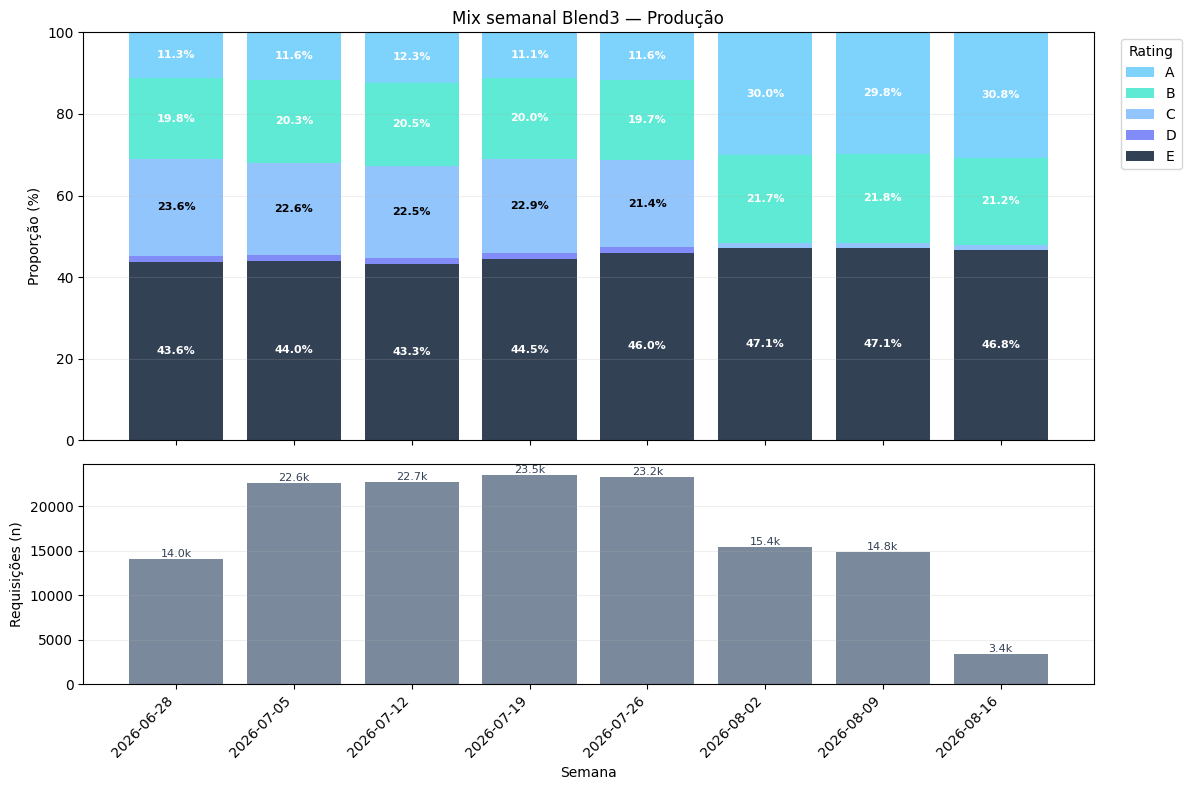

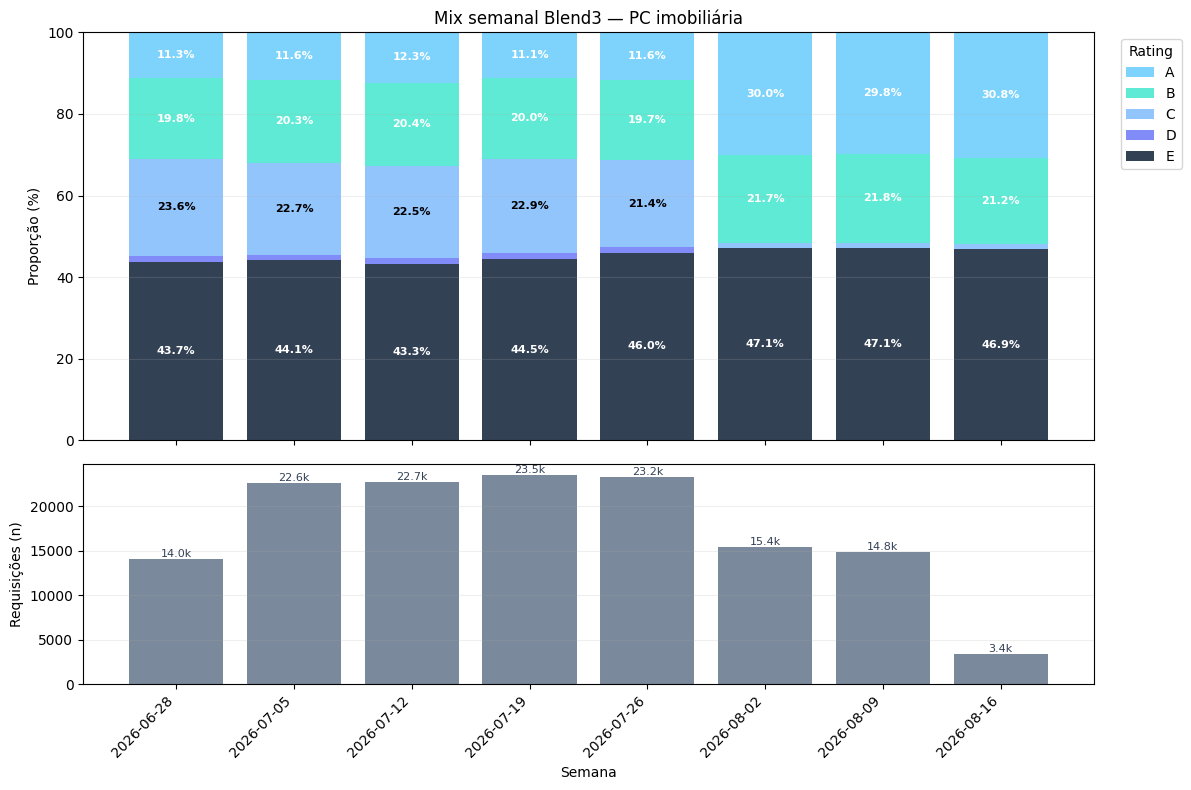

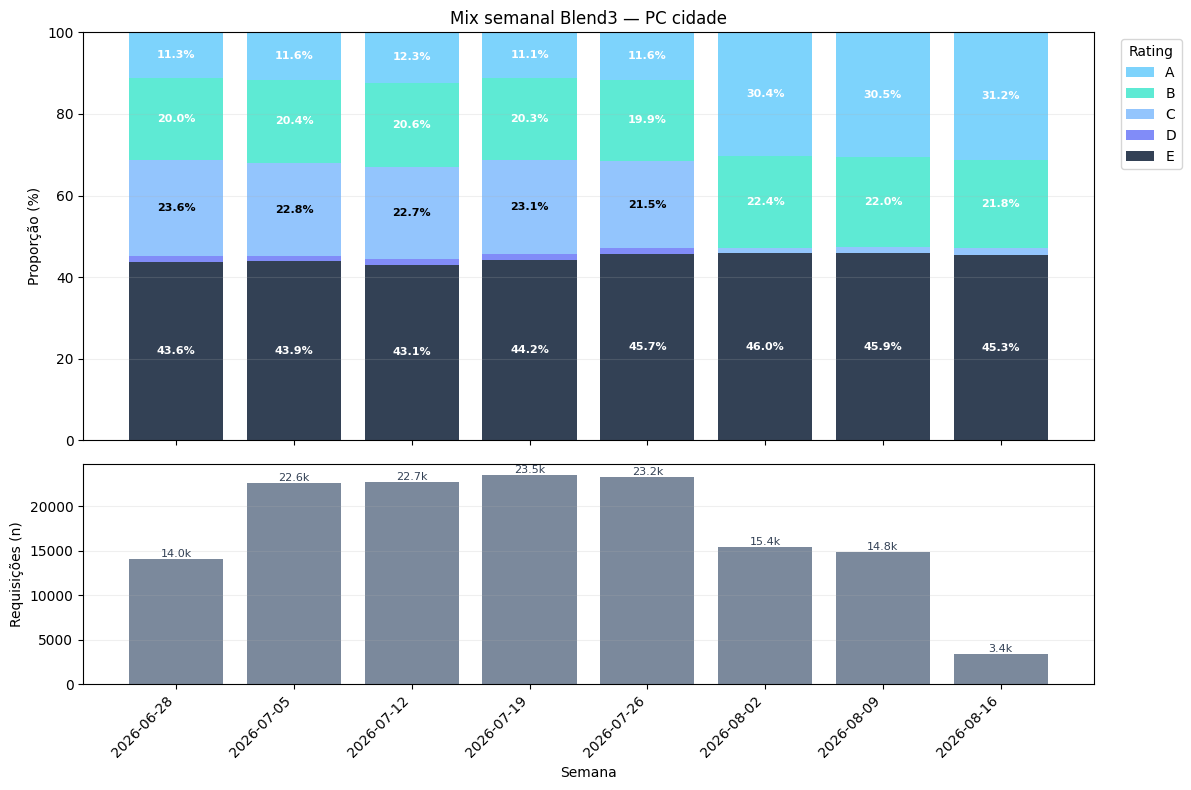

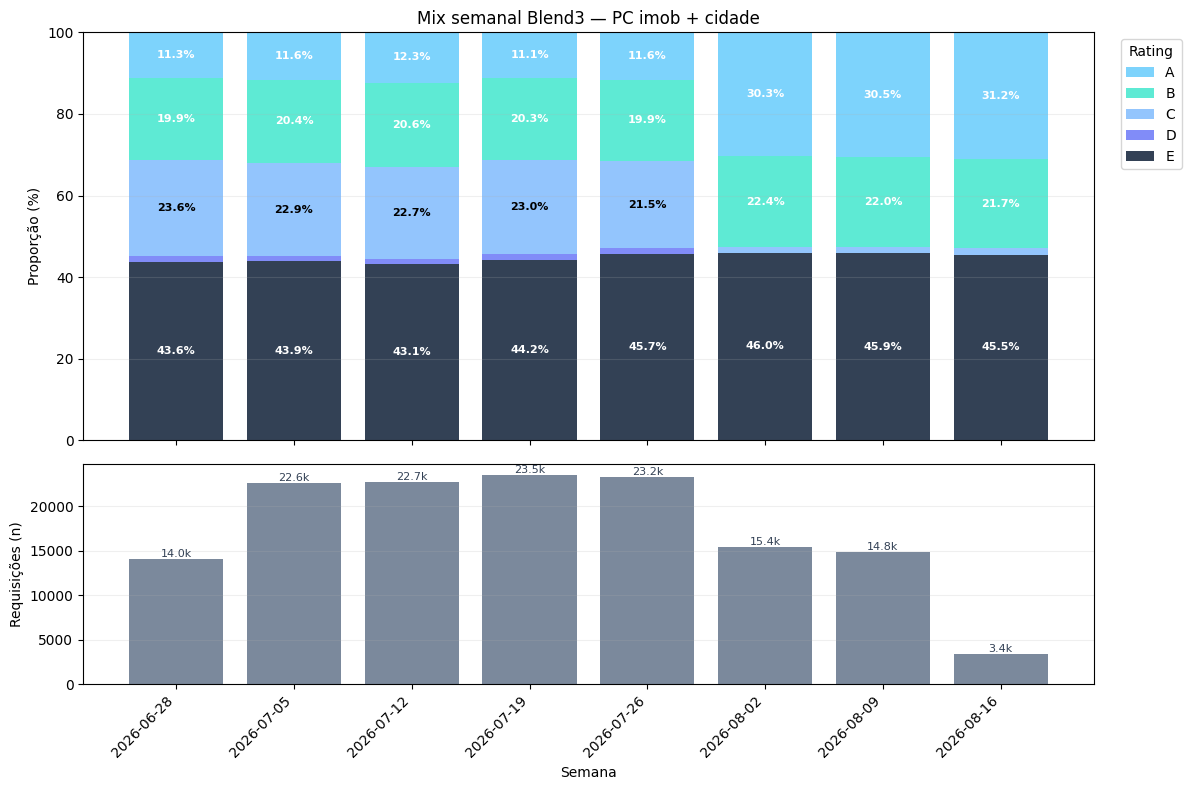

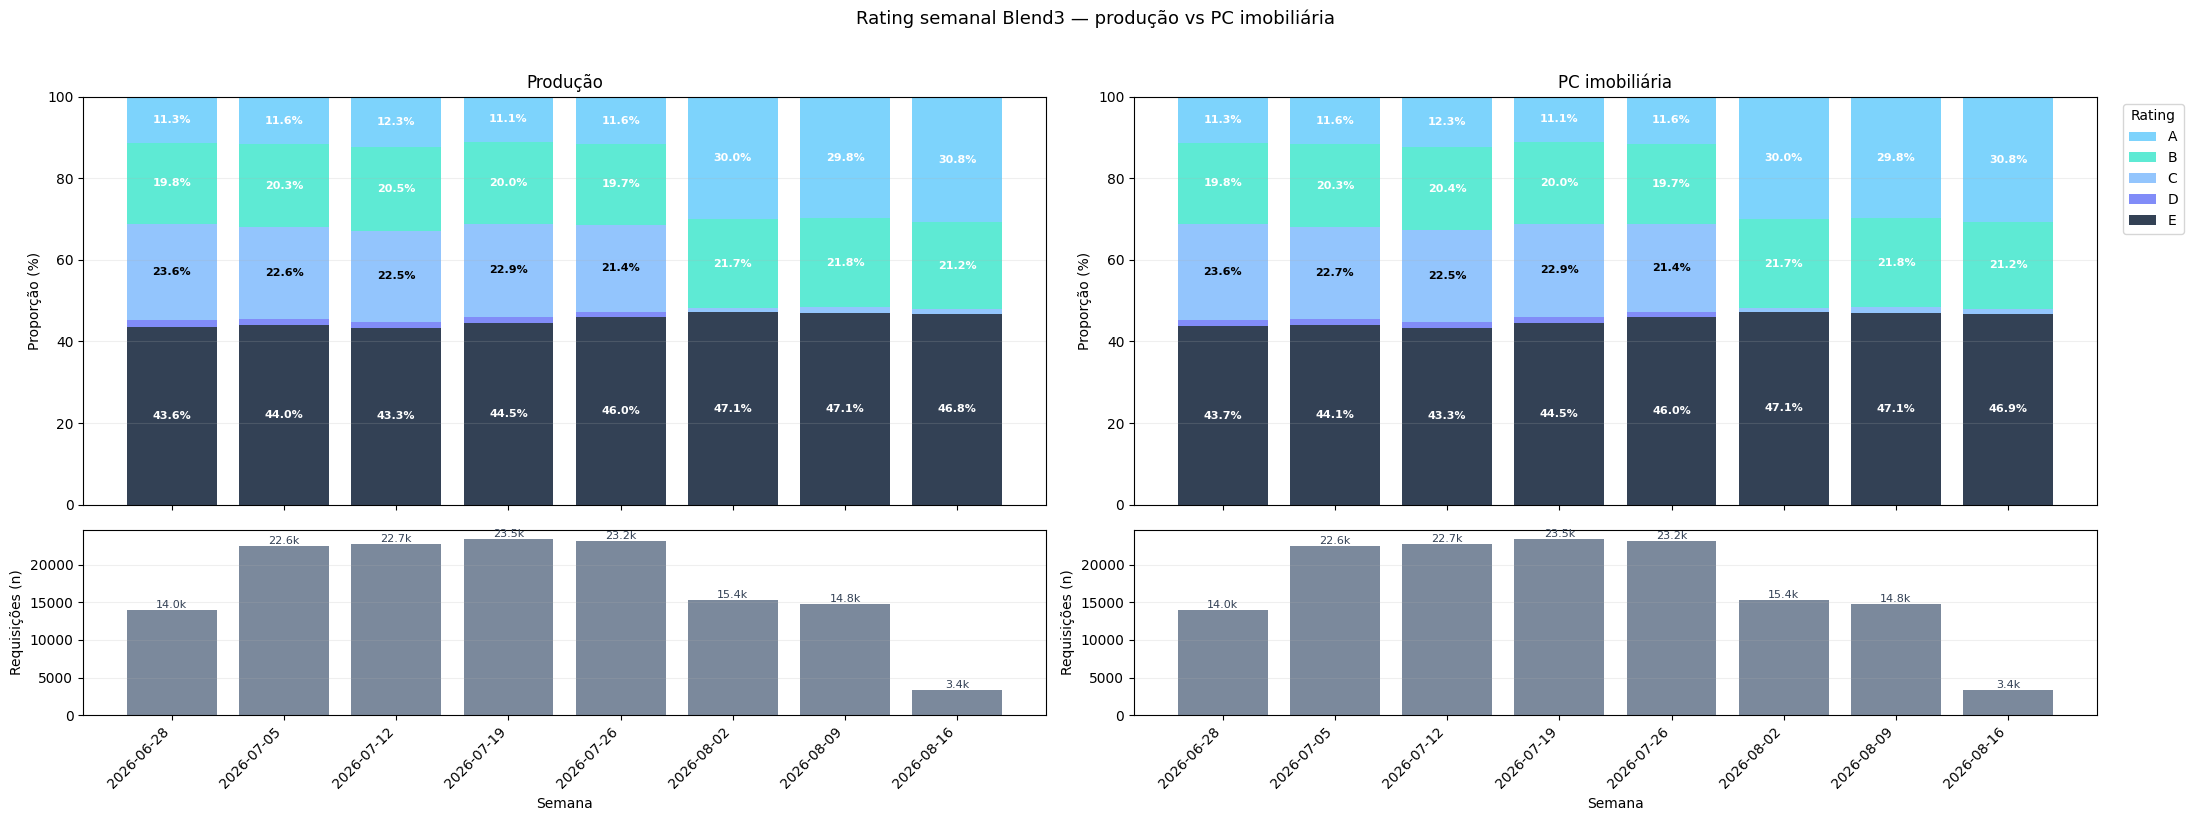

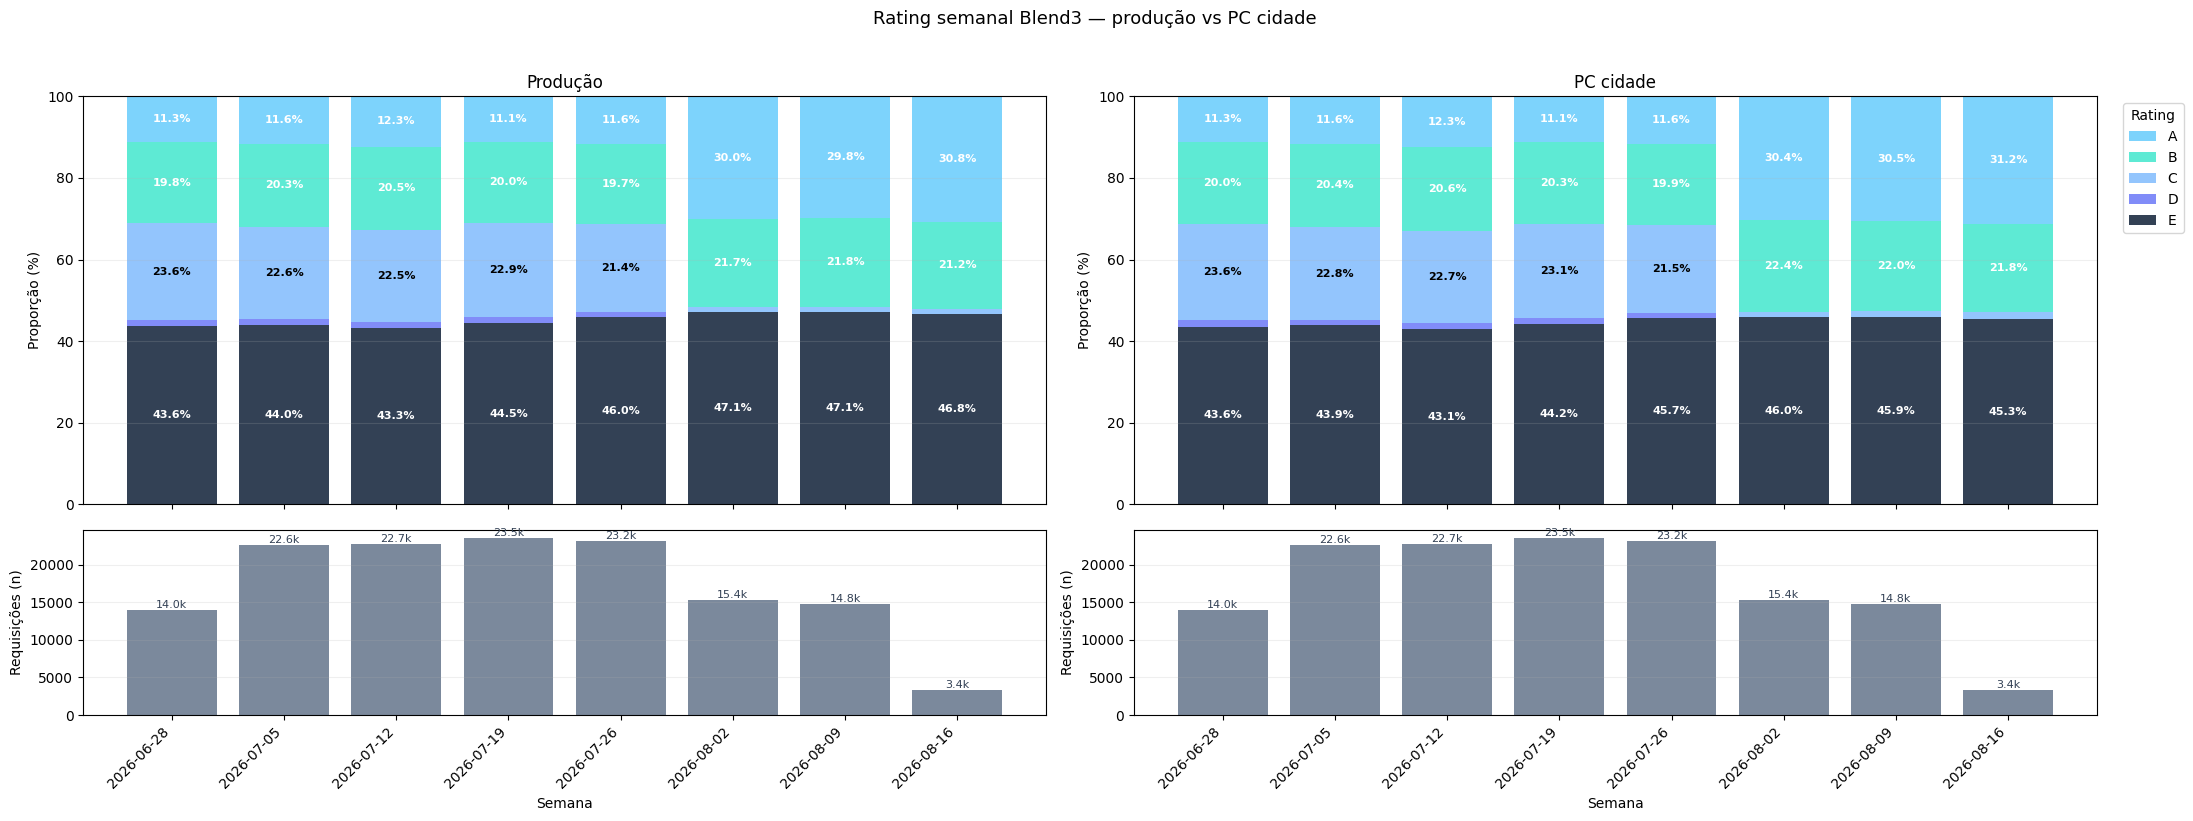

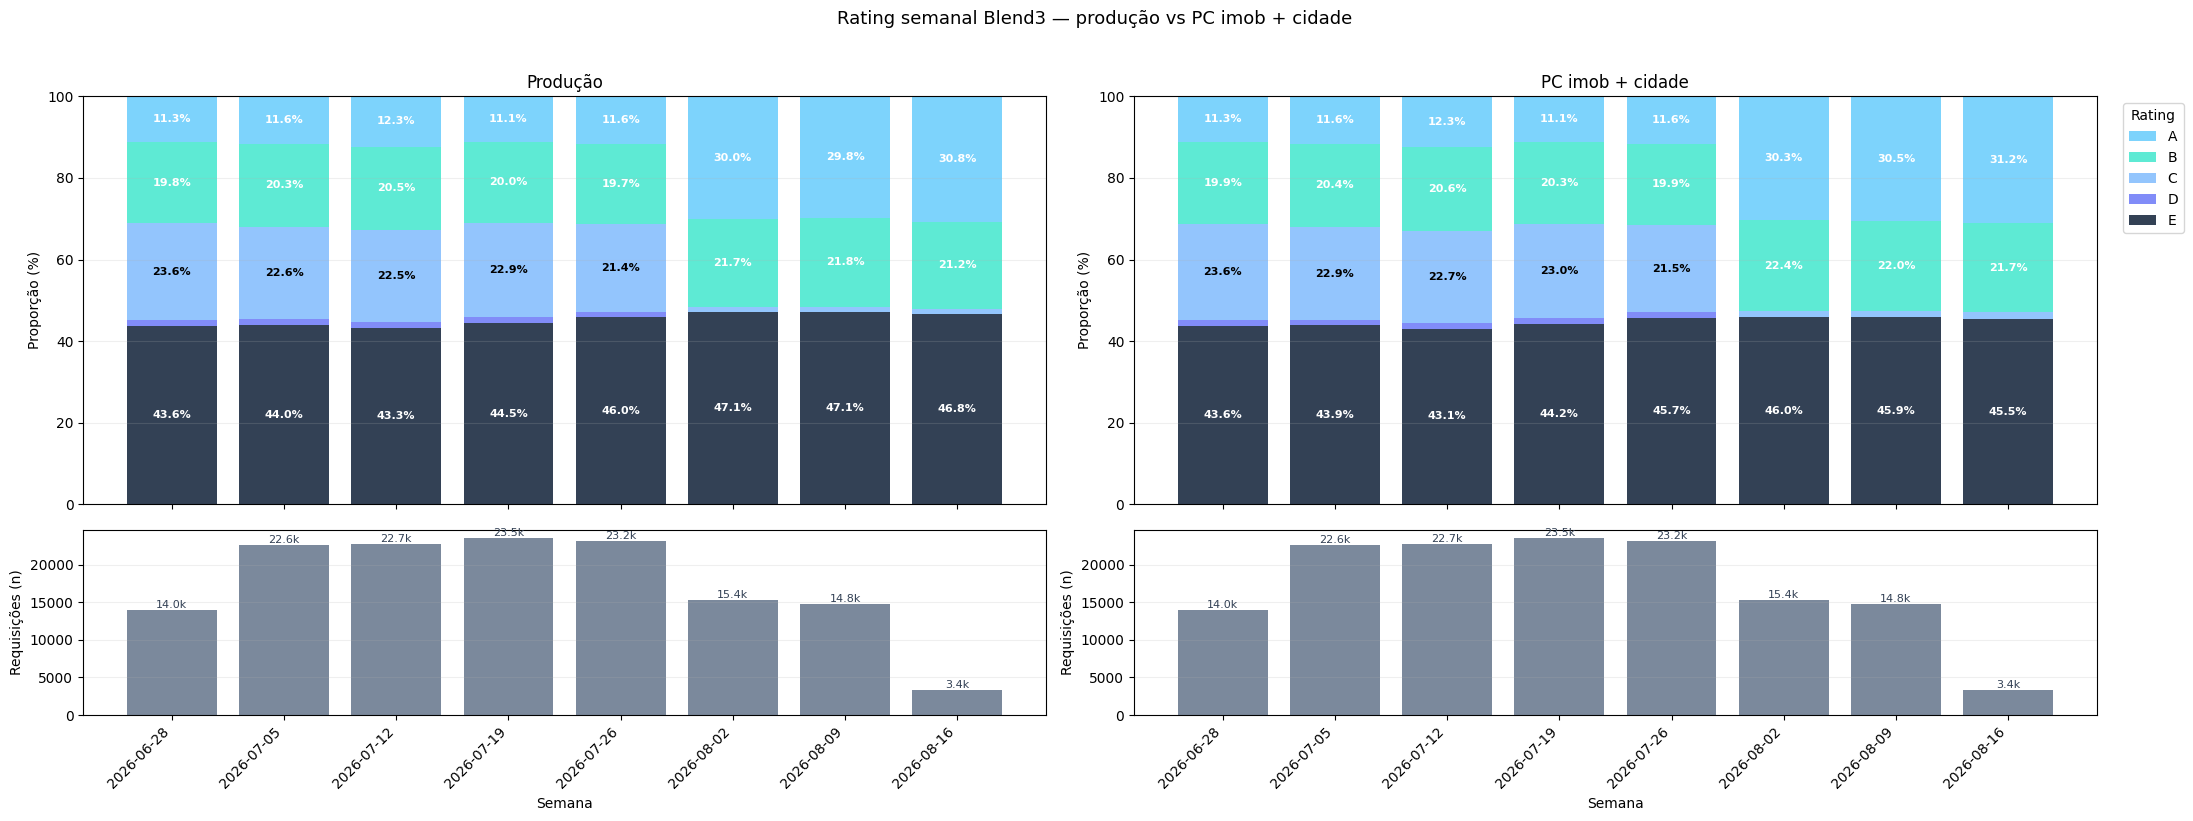

In [623]:
for scen, label in [
    ("prod", "Produção"),
    ("agency", "PC imobiliária"),
    ("city", "PC cidade"),
    ("ambos", "PC imob + cidade"),
]:
    plot_weekly_mix(
        df_blend3_cmp,
        category_col=f"rating_manual_blend3_{scen}",
        title=f"Mix semanal Blend3 — {label}",
        category_order=RATING_ORDER,
        color_map=RATING_COLOR_MAP,
        text_color_map=RATING_TEXT_COLOR_MAP,
        reverse_stack=True,
        legend_title="Rating",
        min_label_pct=3.0,
    )

for scen, label in [
    ("agency", "PC imobiliária"),
    ("city", "PC cidade"),
    ("ambos", "PC imob + cidade"),
]:
    plot_weekly_rating_comparison(
        df_blend3_cmp,
        title=f"Rating semanal Blend3 — produção vs {label}",
        production_rating_col="rating_manual_blend3_prod",
        simulated_rating_col=f"rating_manual_blend3_{scen}",
        category_order=RATING_ORDER,
        color_map=RATING_COLOR_MAP,
        text_color_map=RATING_TEXT_COLOR_MAP,
        reverse_stack=True,
        min_label_pct=3.0,
        production_title="Produção",
        simulated_title=label,
    )


### Blend3 — matriz de migração

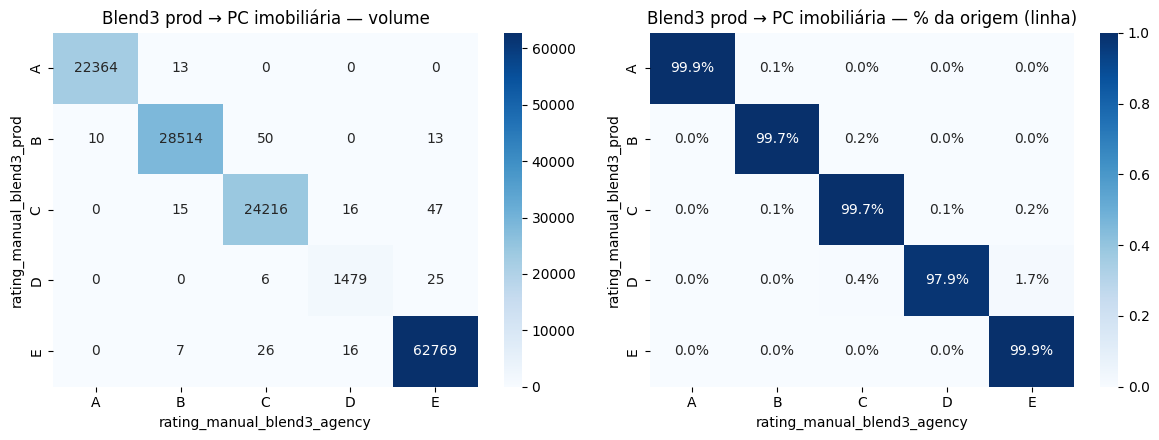

Blend3 prod → PC imobiliária: n=139,586 | permanência=99.8%


rating_manual_blend3_agency,A,B,C,D,E,total
rating_manual_blend3_prod,,,,,,
A,22364,13,0,0,0,22377
B,10,28514,50,0,13,28587
C,0,15,24216,16,47,24294
D,0,0,6,1479,25,1510
E,0,7,26,16,62769,62818


rating_manual_blend3_agency,A,B,C,D,E,total
rating_manual_blend3_prod,,,,,,
A,0.999,0.001,0.000,0.000,0.000,1.0
B,0.000,0.997,0.002,0.000,0.000,1.0
C,0.000,0.001,0.997,0.001,0.002,1.0
D,0.000,0.000,0.004,0.979,0.017,1.0
E,0.000,0.000,0.000,0.000,0.999,1.0


,volume_total,volume_match,volume_mismatch,pct_match,pct_mismatch,transitions_distinct
0,139586,139342,244,99.83,0.17,20


,rating_manual_blend3_prod,rating_manual_blend3_agency,volume,is_match,pct_total,pct_mismatch,rating_delta,transition
0,A,A,22364,True,16.02,0.00,0,A → A
1,A,B,13,False,0.01,5.33,1,A → B
2,A,C,0,False,0.00,0.00,2,A → C
3,A,D,0,False,0.00,0.00,3,A → D
4,A,E,0,False,0.00,0.00,4,A → E
5,B,A,10,False,0.01,4.10,-1,B → A
6,B,B,28514,True,20.43,0.00,0,B → B
7,B,C,50,False,0.04,20.49,1,B → C
8,B,D,0,False,0.00,0.00,2,B → D
9,B,E,13,False,0.01,5.33,3,B → E


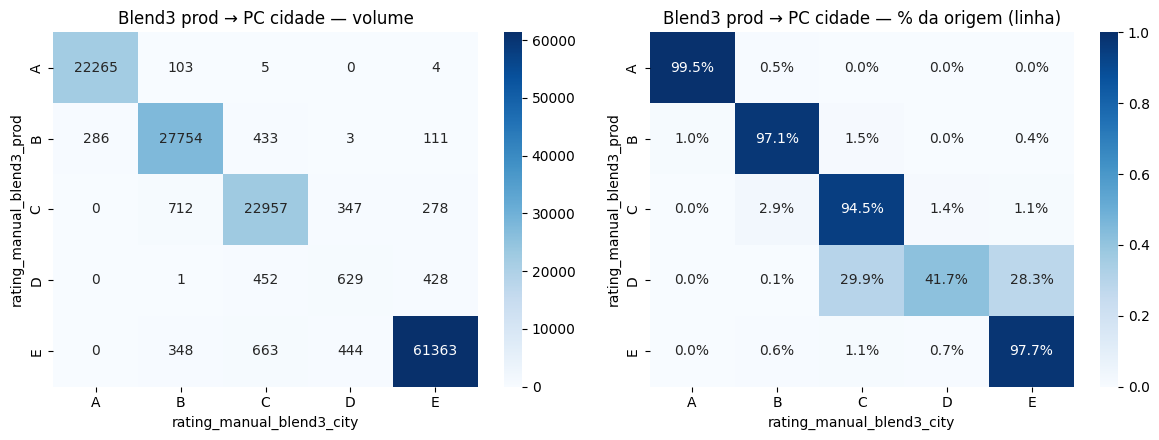

Blend3 prod → PC cidade: n=139,586 | permanência=96.7%


rating_manual_blend3_city,A,B,C,D,E,total
rating_manual_blend3_prod,,,,,,
A,22265,103,5,0,4,22377
B,286,27754,433,3,111,28587
C,0,712,22957,347,278,24294
D,0,1,452,629,428,1510
E,0,348,663,444,61363,62818


rating_manual_blend3_city,A,B,C,D,E,total
rating_manual_blend3_prod,,,,,,
A,0.995,0.005,0.000,0.000,0.000,1.0
B,0.010,0.971,0.015,0.000,0.004,1.0
C,0.000,0.029,0.945,0.014,0.011,1.0
D,0.000,0.001,0.299,0.417,0.283,1.0
E,0.000,0.006,0.011,0.007,0.977,1.0


,volume_total,volume_match,volume_mismatch,pct_match,pct_mismatch,transitions_distinct
0,139586,134968,4618,96.69,3.31,20


,rating_manual_blend3_prod,rating_manual_blend3_city,volume,is_match,pct_total,pct_mismatch,rating_delta,transition
0,A,A,22265,True,15.95,0.00,0,A → A
1,A,B,103,False,0.07,2.23,1,A → B
2,A,C,5,False,0.00,0.11,2,A → C
3,A,D,0,False,0.00,0.00,3,A → D
4,A,E,4,False,0.00,0.09,4,A → E
5,B,A,286,False,0.20,6.19,-1,B → A
6,B,B,27754,True,19.88,0.00,0,B → B
7,B,C,433,False,0.31,9.38,1,B → C
8,B,D,3,False,0.00,0.06,2,B → D
9,B,E,111,False,0.08,2.40,3,B → E


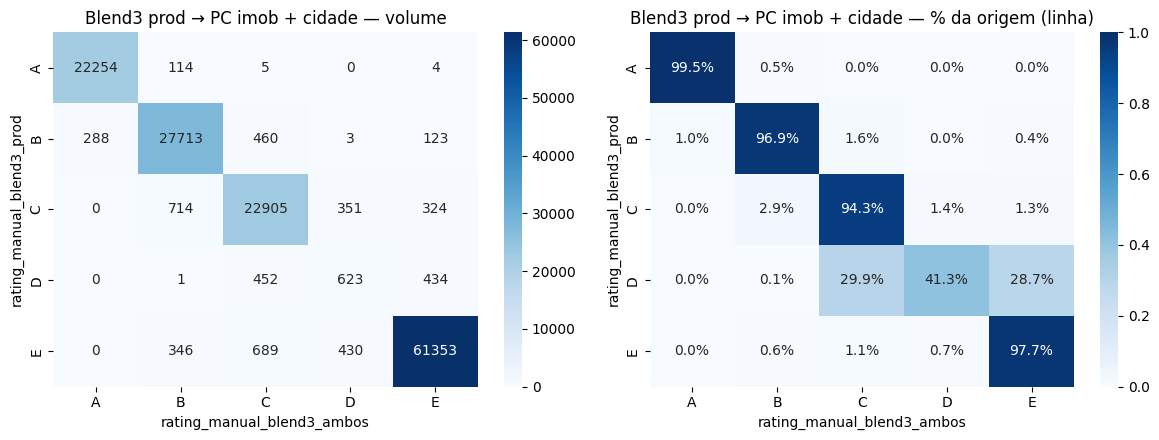

Blend3 prod → PC imob + cidade: n=139,586 | permanência=96.6%


rating_manual_blend3_ambos,A,B,C,D,E,total
rating_manual_blend3_prod,,,,,,
A,22254,114,5,0,4,22377
B,288,27713,460,3,123,28587
C,0,714,22905,351,324,24294
D,0,1,452,623,434,1510
E,0,346,689,430,61353,62818


rating_manual_blend3_ambos,A,B,C,D,E,total
rating_manual_blend3_prod,,,,,,
A,0.995,0.005,0.000,0.000,0.000,1.0
B,0.010,0.969,0.016,0.000,0.004,1.0
C,0.000,0.029,0.943,0.014,0.013,1.0
D,0.000,0.001,0.299,0.413,0.287,1.0
E,0.000,0.006,0.011,0.007,0.977,1.0


,volume_total,volume_match,volume_mismatch,pct_match,pct_mismatch,transitions_distinct
0,139586,134848,4738,96.61,3.39,20


,rating_manual_blend3_prod,rating_manual_blend3_ambos,volume,is_match,pct_total,pct_mismatch,rating_delta,transition
0,A,A,22254,True,15.94,0.00,0,A → A
1,A,B,114,False,0.08,2.41,1,A → B
2,A,C,5,False,0.00,0.11,2,A → C
3,A,D,0,False,0.00,0.00,3,A → D
4,A,E,4,False,0.00,0.08,4,A → E
5,B,A,288,False,0.21,6.08,-1,B → A
6,B,B,27713,True,19.85,0.00,0,B → B
7,B,C,460,False,0.33,9.71,1,B → C
8,B,D,3,False,0.00,0.06,2,B → D
9,B,E,123,False,0.09,2.60,3,B → E


In [624]:
from importlib import reload
import funcoes_monitoramento as _fm_mon
reload(_fm_mon)
from funcoes_monitoramento import build_rating_mismatch_table, build_rating_match_summary

for scen, label in [
    ("agency", "PC imobiliária"),
    ("city", "PC cidade"),
    ("ambos", "PC imob + cidade"),
]:
    plot_rating_migration(
        df_blend3_cmp,
        "rating_manual_blend3_prod",
        f"rating_manual_blend3_{scen}",
        f"Blend3 prod → {label}",
    )


### Blend4 — mix semanal (domingo a sábado)

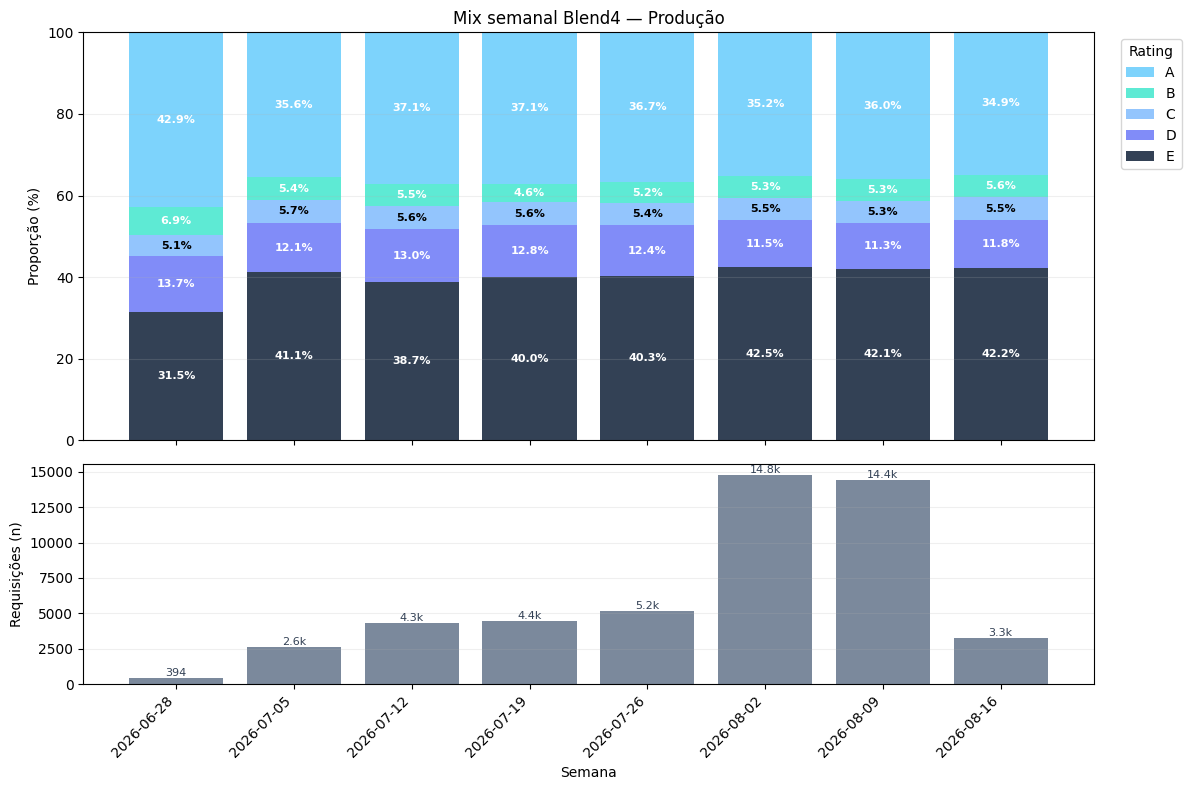

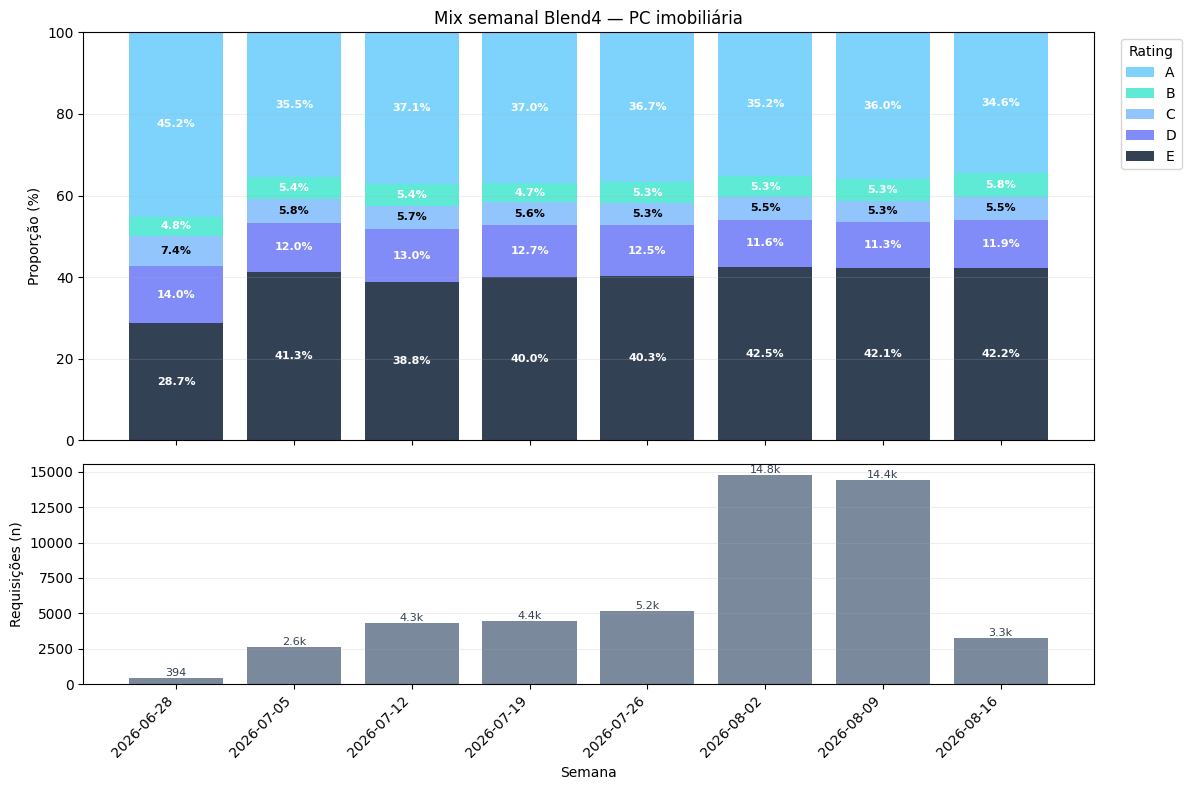

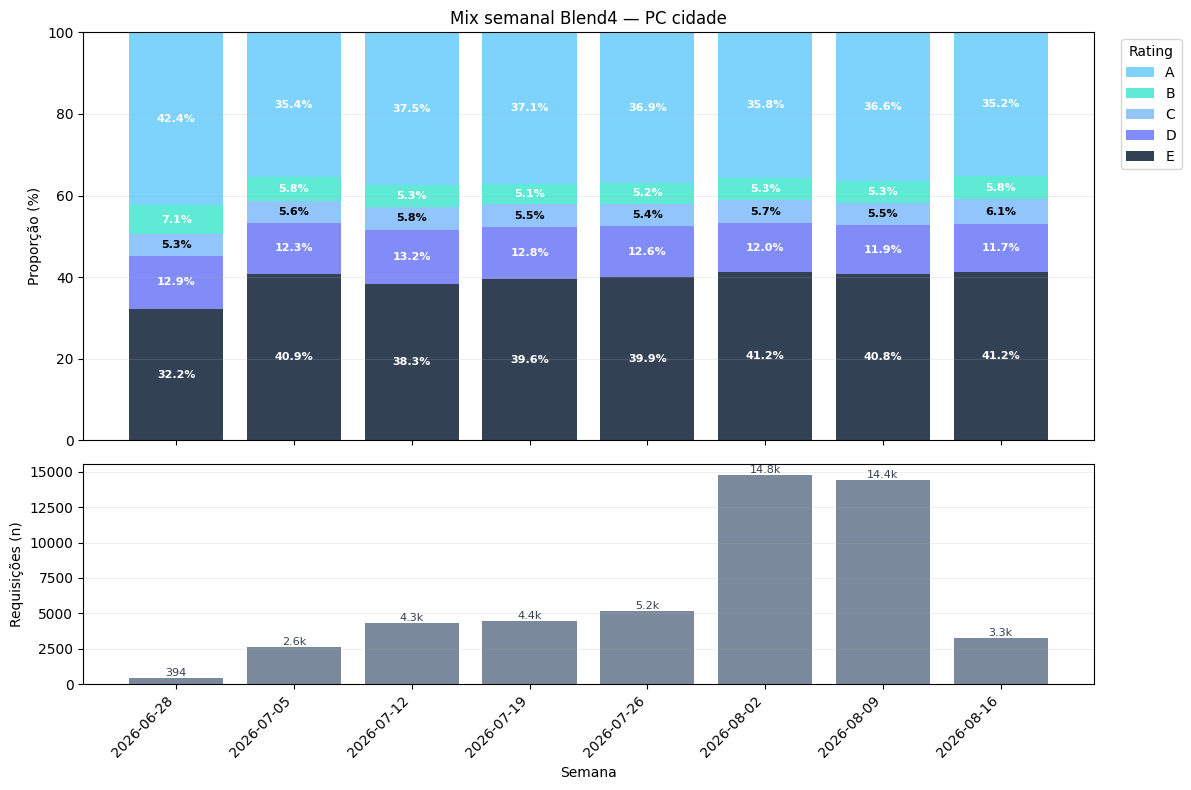

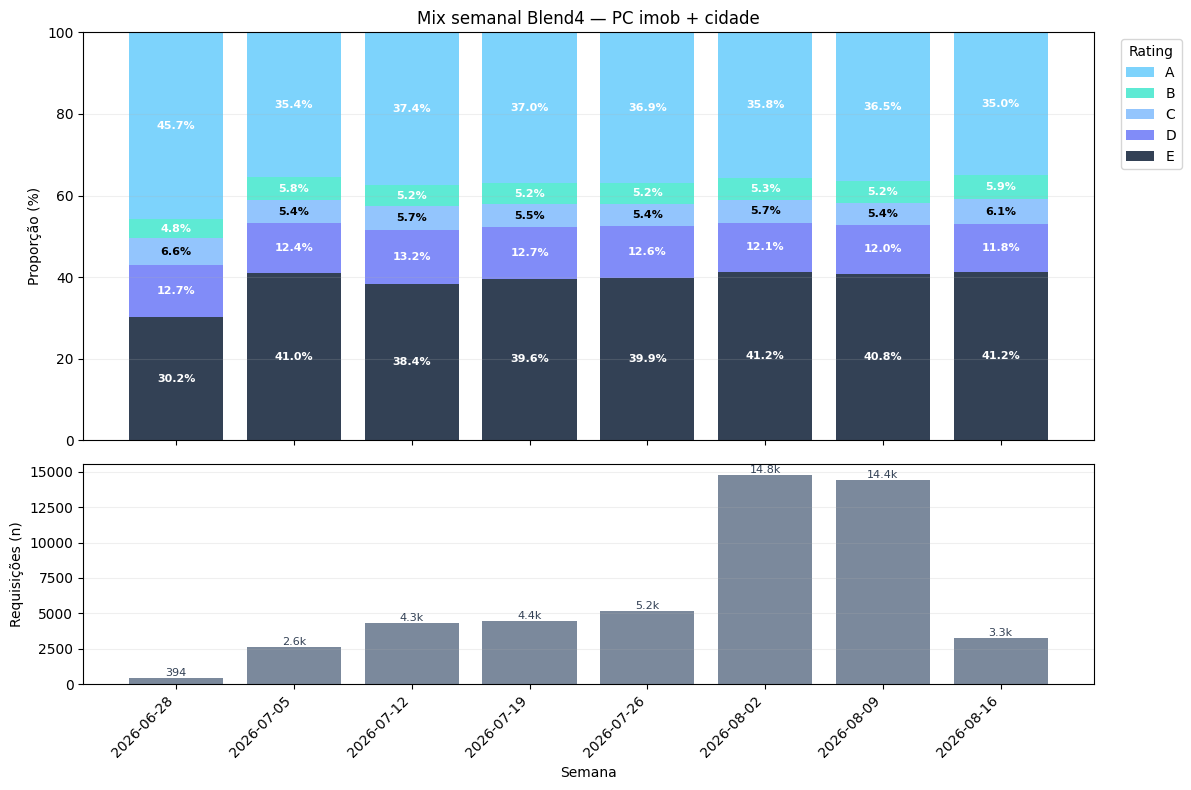

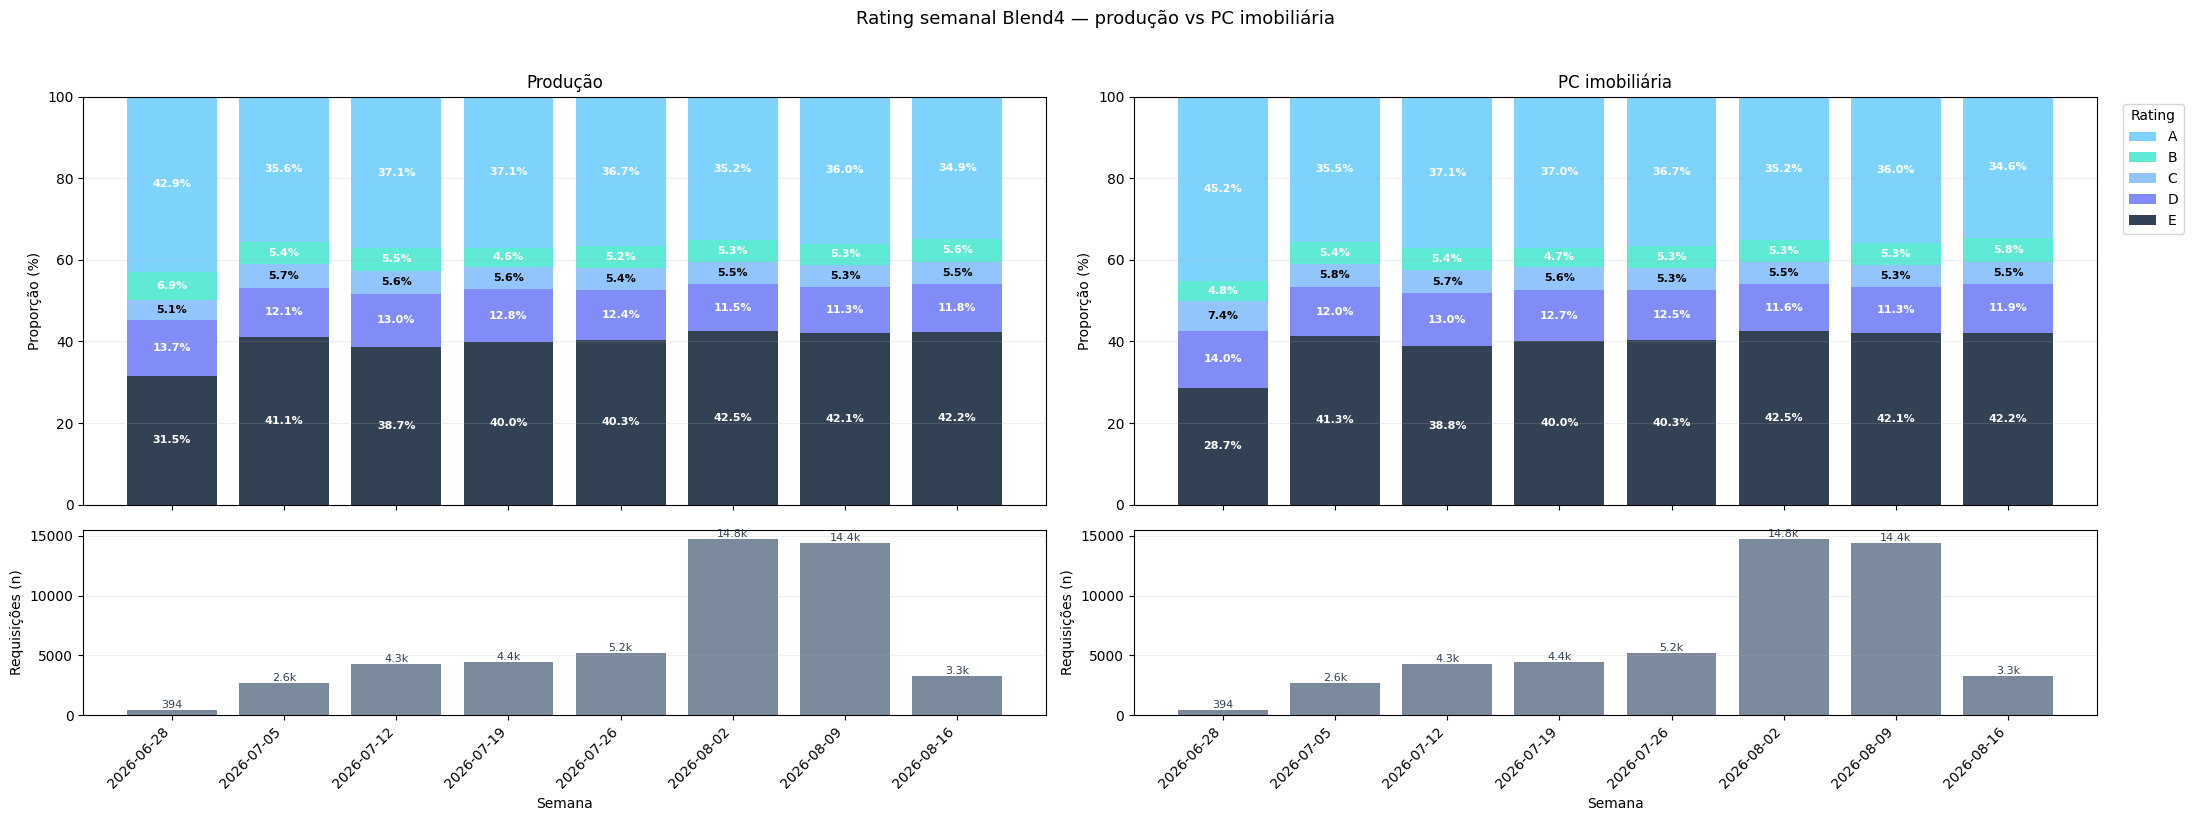

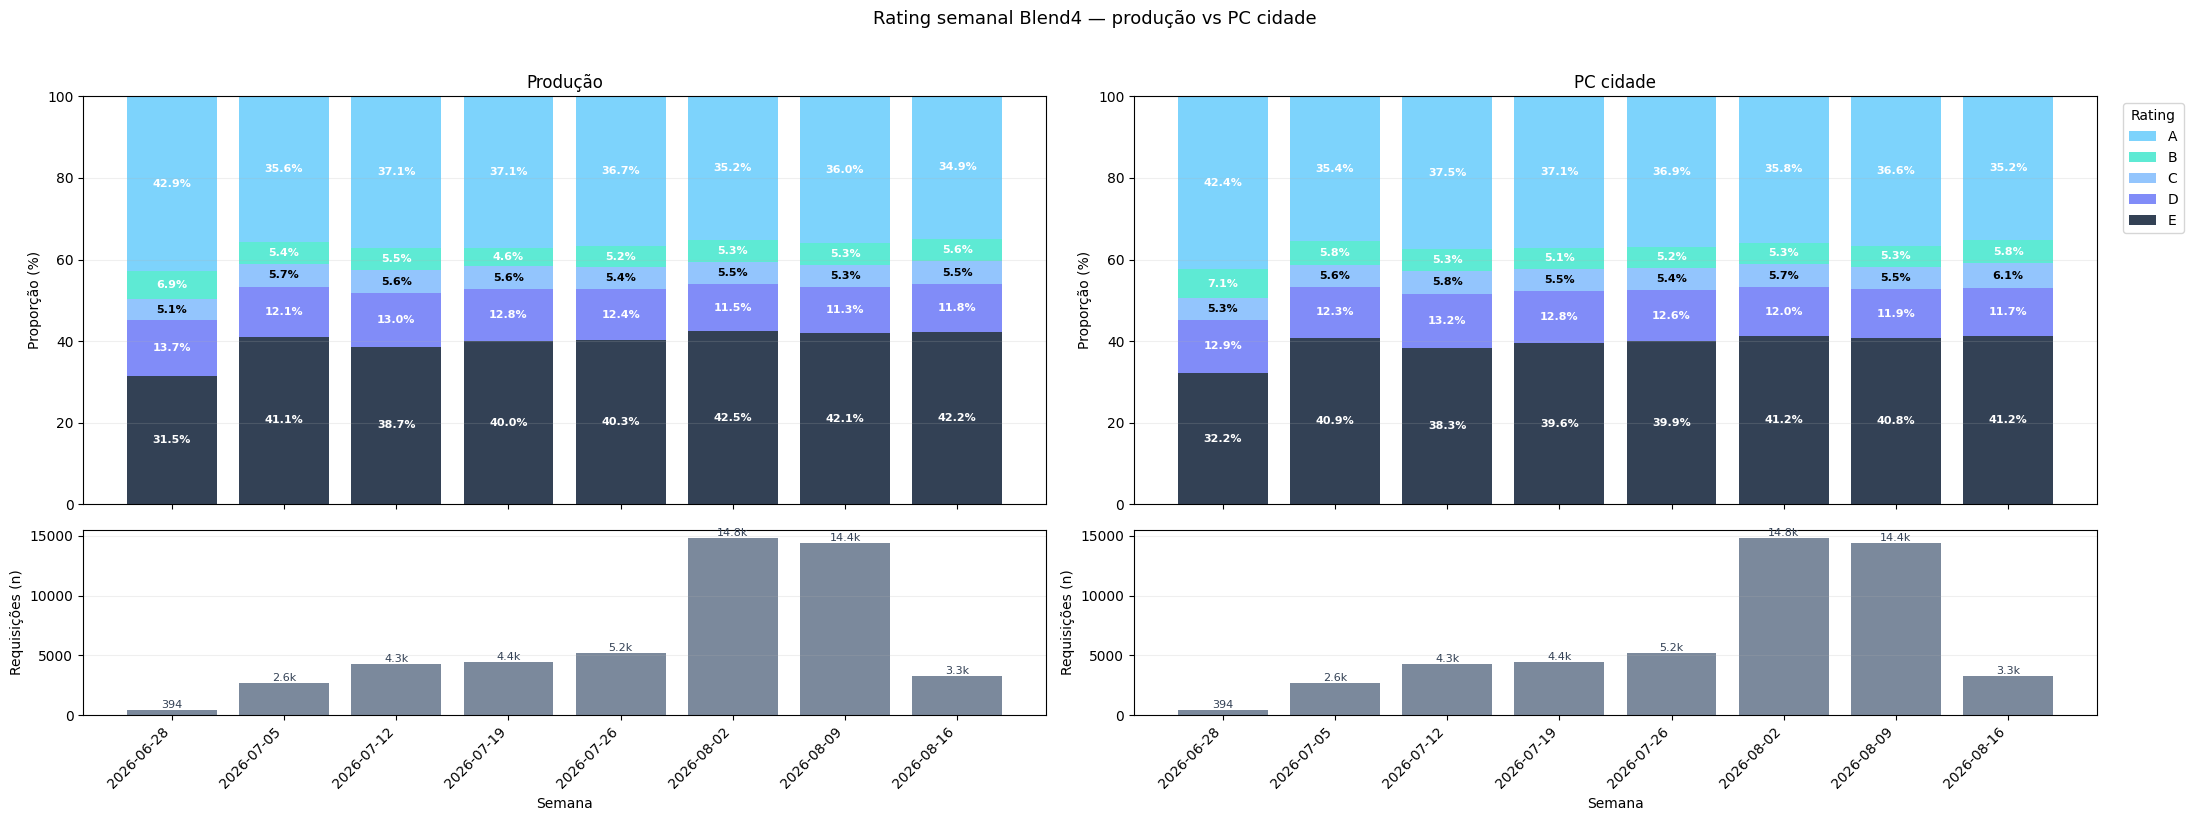

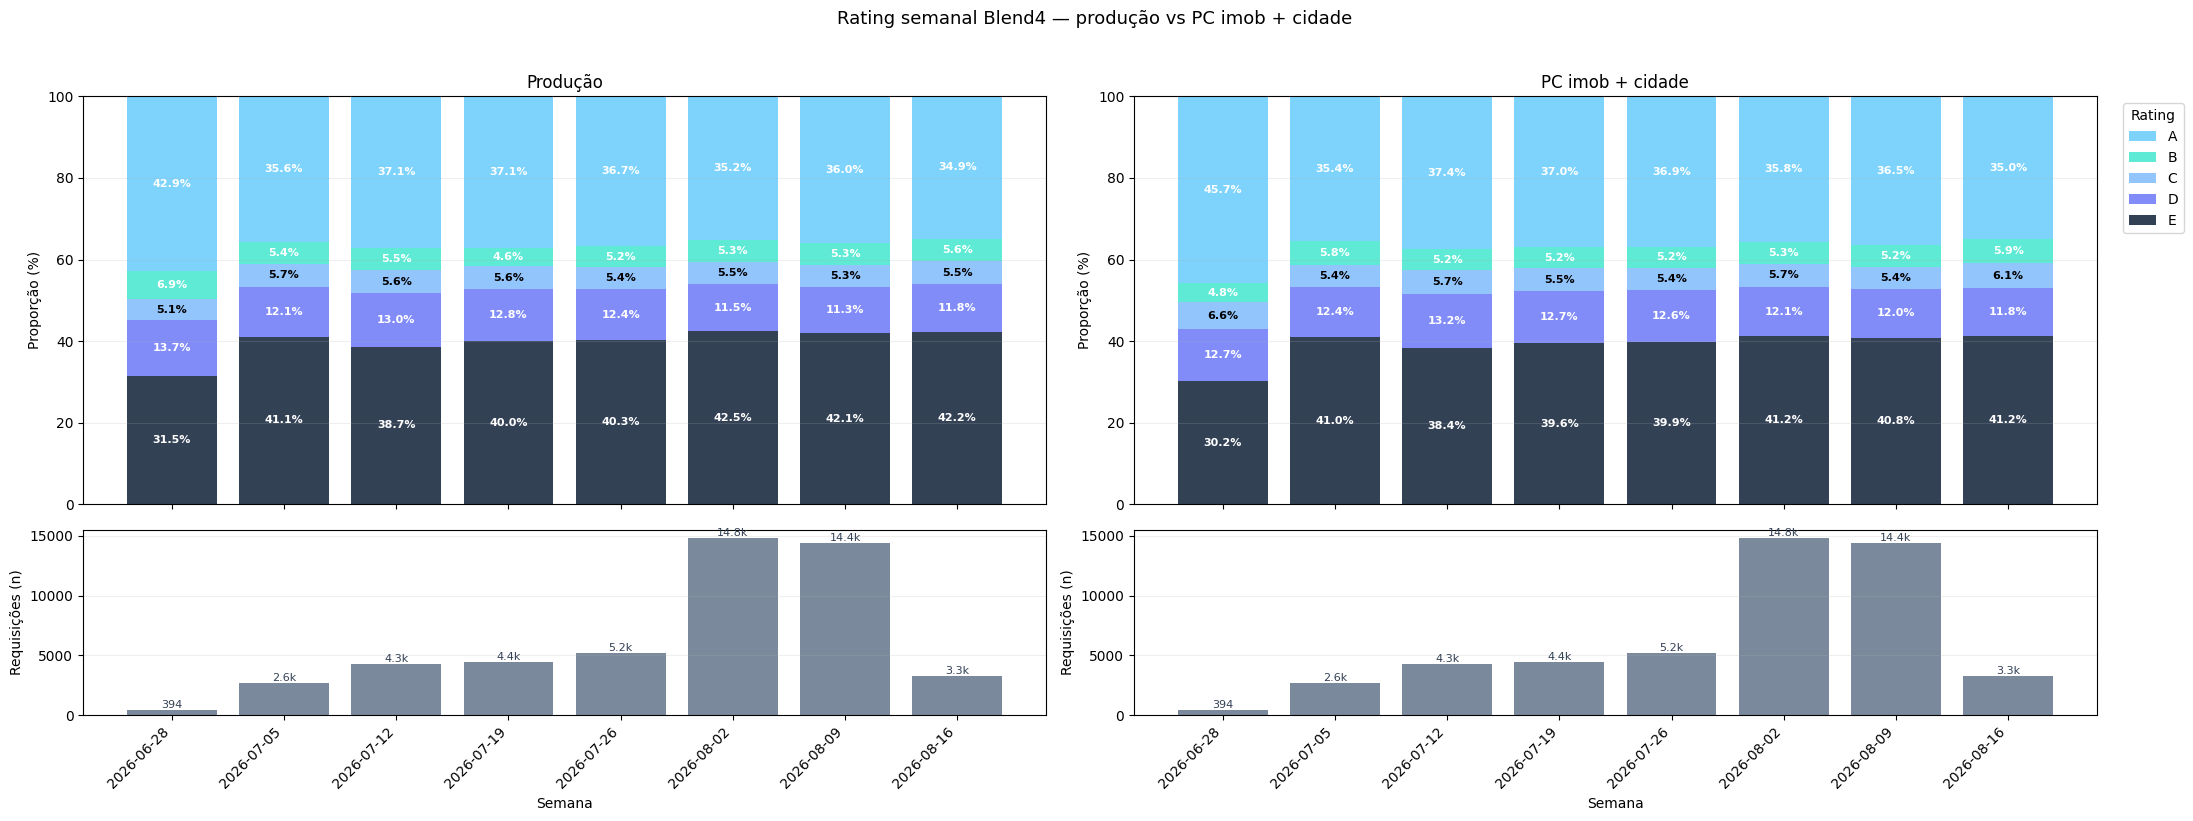

In [625]:
for scen, label in [
    ("prod", "Produção"),
    ("agency", "PC imobiliária"),
    ("city", "PC cidade"),
    ("ambos", "PC imob + cidade"),
]:
    plot_weekly_mix(
        df_blend4_cmp,
        category_col=f"rating_manual_blend4_{scen}",
        title=f"Mix semanal Blend4 — {label}",
        category_order=RATING_ORDER,
        color_map=RATING_COLOR_MAP,
        text_color_map=RATING_TEXT_COLOR_MAP,
        reverse_stack=True,
        legend_title="Rating",
        min_label_pct=3.0,
    )

for scen, label in [
    ("agency", "PC imobiliária"),
    ("city", "PC cidade"),
    ("ambos", "PC imob + cidade"),
]:
    plot_weekly_rating_comparison(
        df_blend4_cmp,
        title=f"Rating semanal Blend4 — produção vs {label}",
        production_rating_col="rating_manual_blend4_prod",
        simulated_rating_col=f"rating_manual_blend4_{scen}",
        category_order=RATING_ORDER,
        color_map=RATING_COLOR_MAP,
        text_color_map=RATING_TEXT_COLOR_MAP,
        reverse_stack=True,
        min_label_pct=3.0,
        production_title="Produção",
        simulated_title=label,
    )


### Blend4 — matriz de migração

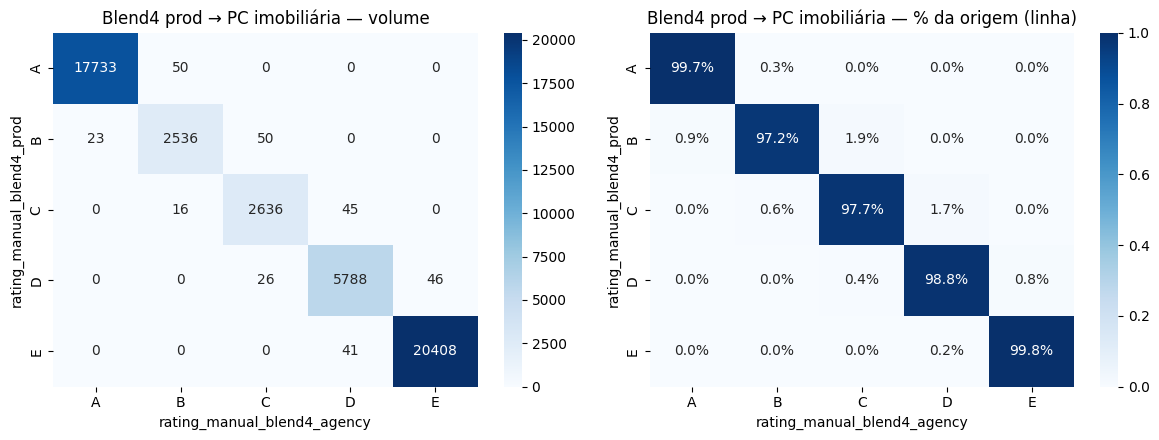

Blend4 prod → PC imobiliária: n=49,398 | permanência=99.4%


rating_manual_blend4_agency,A,B,C,D,E,total
rating_manual_blend4_prod,,,,,,
A,17733,50,0,0,0,17783
B,23,2536,50,0,0,2609
C,0,16,2636,45,0,2697
D,0,0,26,5788,46,5860
E,0,0,0,41,20408,20449


rating_manual_blend4_agency,A,B,C,D,E,total
rating_manual_blend4_prod,,,,,,
A,0.997,0.003,0.000,0.000,0.000,1.0
B,0.009,0.972,0.019,0.000,0.000,1.0
C,0.000,0.006,0.977,0.017,0.000,1.0
D,0.000,0.000,0.004,0.988,0.008,1.0
E,0.000,0.000,0.000,0.002,0.998,1.0


,volume_total,volume_match,volume_mismatch,pct_match,pct_mismatch,transitions_distinct
0,49398,49101,297,99.4,0.6,20


,rating_manual_blend4_prod,rating_manual_blend4_agency,volume,is_match,pct_total,pct_mismatch,rating_delta,transition
0,A,A,17733,True,35.90,0.00,0,A → A
1,A,B,50,False,0.10,16.84,1,A → B
2,A,C,0,False,0.00,0.00,2,A → C
3,A,D,0,False,0.00,0.00,3,A → D
4,A,E,0,False,0.00,0.00,4,A → E
5,B,A,23,False,0.05,7.74,-1,B → A
6,B,B,2536,True,5.13,0.00,0,B → B
7,B,C,50,False,0.10,16.84,1,B → C
8,B,D,0,False,0.00,0.00,2,B → D
9,B,E,0,False,0.00,0.00,3,B → E


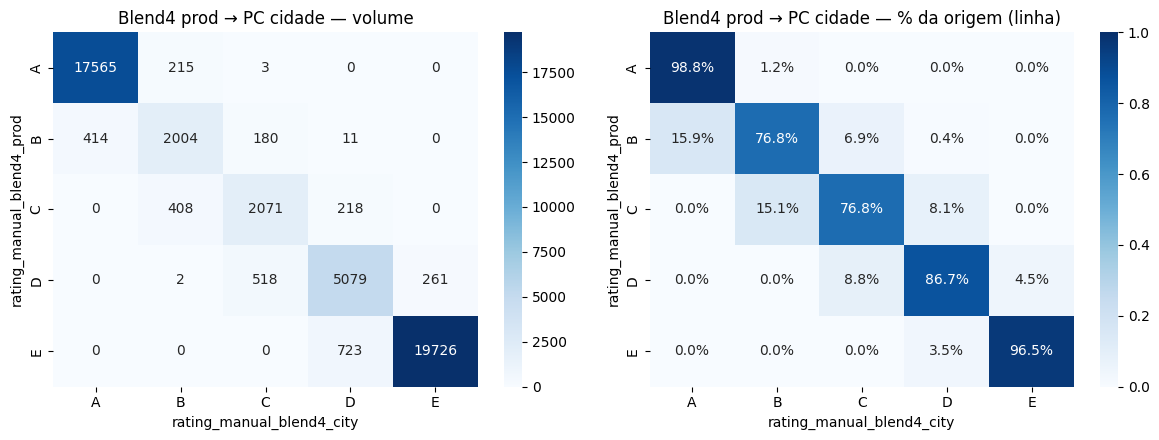

Blend4 prod → PC cidade: n=49,398 | permanência=94.0%


rating_manual_blend4_city,A,B,C,D,E,total
rating_manual_blend4_prod,,,,,,
A,17565,215,3,0,0,17783
B,414,2004,180,11,0,2609
C,0,408,2071,218,0,2697
D,0,2,518,5079,261,5860
E,0,0,0,723,19726,20449


rating_manual_blend4_city,A,B,C,D,E,total
rating_manual_blend4_prod,,,,,,
A,0.988,0.012,0.000,0.000,0.000,1.0
B,0.159,0.768,0.069,0.004,0.000,1.0
C,0.000,0.151,0.768,0.081,0.000,1.0
D,0.000,0.000,0.088,0.867,0.045,1.0
E,0.000,0.000,0.000,0.035,0.965,1.0


,volume_total,volume_match,volume_mismatch,pct_match,pct_mismatch,transitions_distinct
0,49398,46445,2953,94.02,5.98,20


,rating_manual_blend4_prod,rating_manual_blend4_city,volume,is_match,pct_total,pct_mismatch,rating_delta,transition
0,A,A,17565,True,35.56,0.00,0,A → A
1,A,B,215,False,0.44,7.28,1,A → B
2,A,C,3,False,0.01,0.10,2,A → C
3,A,D,0,False,0.00,0.00,3,A → D
4,A,E,0,False,0.00,0.00,4,A → E
5,B,A,414,False,0.84,14.02,-1,B → A
6,B,B,2004,True,4.06,0.00,0,B → B
7,B,C,180,False,0.36,6.10,1,B → C
8,B,D,11,False,0.02,0.37,2,B → D
9,B,E,0,False,0.00,0.00,3,B → E


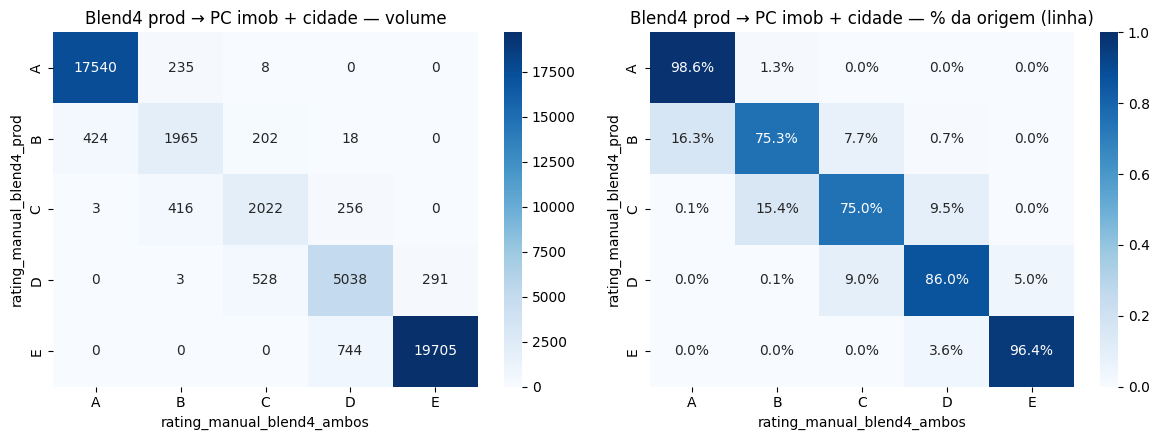

Blend4 prod → PC imob + cidade: n=49,398 | permanência=93.7%


rating_manual_blend4_ambos,A,B,C,D,E,total
rating_manual_blend4_prod,,,,,,
A,17540,235,8,0,0,17783
B,424,1965,202,18,0,2609
C,3,416,2022,256,0,2697
D,0,3,528,5038,291,5860
E,0,0,0,744,19705,20449


rating_manual_blend4_ambos,A,B,C,D,E,total
rating_manual_blend4_prod,,,,,,
A,0.986,0.013,0.000,0.000,0.000,1.0
B,0.163,0.753,0.077,0.007,0.000,1.0
C,0.001,0.154,0.750,0.095,0.000,1.0
D,0.000,0.001,0.090,0.860,0.050,1.0
E,0.000,0.000,0.000,0.036,0.964,1.0


,volume_total,volume_match,volume_mismatch,pct_match,pct_mismatch,transitions_distinct
0,49398,46270,3128,93.67,6.33,20


,rating_manual_blend4_prod,rating_manual_blend4_ambos,volume,is_match,pct_total,pct_mismatch,rating_delta,transition
0,A,A,17540,True,35.51,0.00,0,A → A
1,A,B,235,False,0.48,7.51,1,A → B
2,A,C,8,False,0.02,0.26,2,A → C
3,A,D,0,False,0.00,0.00,3,A → D
4,A,E,0,False,0.00,0.00,4,A → E
5,B,A,424,False,0.86,13.55,-1,B → A
6,B,B,1965,True,3.98,0.00,0,B → B
7,B,C,202,False,0.41,6.46,1,B → C
8,B,D,18,False,0.04,0.58,2,B → D
9,B,E,0,False,0.00,0.00,3,B → E


In [626]:
from importlib import reload
import funcoes_monitoramento as _fm_mon
reload(_fm_mon)
from funcoes_monitoramento import build_rating_mismatch_table, build_rating_match_summary

for scen, label in [
    ("agency", "PC imobiliária"),
    ("city", "PC cidade"),
    ("ambos", "PC imob + cidade"),
]:
    plot_rating_migration(
        df_blend4_cmp,
        "rating_manual_blend4_prod",
        f"rating_manual_blend4_{scen}",
        f"Blend4 prod → {label}",
    )


## Matriz de Migração Semanal

In [628]:
# RATING_ORDER = ["A", "B", "C", "D", "E"]

# SCENARIOS = [
#     ("agency", "PC imobiliária"),
#     ("city", "PC cidade"),
#     ("ambos", "PC imob + cidade"),
# ]

# MODELS = [
#     ("Blend3", df_blend3_cmp, "rating_manual_blend3_prod", "rating_manual_blend3_{scen}"),
#     ("Blend4", df_blend4_cmp, "rating_manual_blend4_prod", "rating_manual_blend4_{scen}"),
# ]


# def matriz_migracao(df, col_from, col_to, week_col="year_week"):
#     work = df.copy()
#     work[col_from] = work[col_from].astype("string").str.strip().str.upper()
#     work[col_to] = work[col_to].astype("string").str.strip().str.upper()
#     work = work[work[col_from].isin(RATING_ORDER) & work[col_to].isin(RATING_ORDER)]

#     for week, g in work.groupby(week_col, sort=True):
#         n = (
#             pd.crosstab(g[col_from], g[col_to])
#             .reindex(index=RATING_ORDER, columns=RATING_ORDER, fill_value=0)
#         )
#         total = int(n.values.sum())
#         if total == 0:
#             continue

#         pct = n.div(total).mul(100)  # % do total de leads da semana
#         stay = np.trace(n.values) / total * 100
#         mudou = 100 - stay

#         print(f"\n=== {week} | n={total:,} | permanência={stay:.1f}% | mudou={mudou:.1f}% ===")
#         display(n.assign(total=n.sum(axis=1)))
#         display(
#             pct.round(1)
#             .assign(total=pct.sum(axis=1).round(1))
#             .style.format("{:.1f}%")
#             .background_gradient(cmap="Blues", axis=None)
#         )


# for model_name, df_cmp, col_from, col_to_tpl in MODELS:
#     for scen, label in SCENARIOS:
#         print(f"\n########## {model_name} | prod → {label} ##########")
#         matriz_migracao(df_cmp, col_from, col_to_tpl.format(scen=scen))

In [629]:
RATING_ORDER = ["A", "B", "C", "D", "E"]

SCENARIOS = [
    ("agency", "PC imobiliária"),
    ("city", "PC cidade"),
    ("ambos", "PC imob + cidade"),
]

MODELS = [
    ("Blend3", df_blend3_cmp, "rating_manual_blend3_prod", "rating_manual_blend3_{scen}"),
    ("Blend4", df_blend4_cmp, "rating_manual_blend4_prod", "rating_manual_blend4_{scen}"),
]


def matrizes_semanais_long(df, col_from, col_to, modelo, cenario, week_col="year_week"):
    work = df.copy()
    work[col_from] = work[col_from].astype("string").str.strip().str.upper()
    work[col_to] = work[col_to].astype("string").str.strip().str.upper()
    work = work[work[col_from].isin(RATING_ORDER) & work[col_to].isin(RATING_ORDER)]

    rows = []
    for week, g in work.groupby(week_col, sort=True):
        n = (
            pd.crosstab(g[col_from], g[col_to])
            .reindex(index=RATING_ORDER, columns=RATING_ORDER, fill_value=0)
        )
        n_semana = int(n.values.sum())
        if n_semana == 0:
            continue

        long = (
            n.stack()
            .rename("volume")
            .reset_index()
        )
        long.columns = ["origem", "destino", "volume"]
        long["modelo"] = modelo
        long["cenario"] = cenario
        long["semana"] = week
        long["n_semana"] = n_semana
        long["pct_semana"] = (long["volume"] / n_semana * 100).round(2)
        long["transicao"] = long["origem"] + " → " + long["destino"]
        long["mudou"] = (long["origem"] != long["destino"]).astype(int)
        rows.append(long)

    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


partes = []
for modelo, df_cmp, col_from, col_to_tpl in MODELS:
    for scen, label in SCENARIOS:
        partes.append(
            matrizes_semanais_long(
                df_cmp, col_from, col_to_tpl.format(scen=scen), modelo, label
            )
        )

df_migracao_sheets = pd.concat(partes, ignore_index=True)[
    ["modelo", "cenario", "semana", "origem", "destino", "transicao",
     "volume", "n_semana", "pct_semana", "mudou"]
]

display(df_migracao_sheets.head(20))

# 1) CSV para File > Import no Google Sheets
out_path = ANALYTICS_DIR / "migracao_rating_semanal_blend3_blend4.csv"
df_migracao_sheets.to_csv(out_path, index=False)
print("salvo em:", out_path)

# 2) copiar e colar (Cmd+V no Sheets)
df_migracao_sheets.to_clipboard(index=False, excel=True)
print("copiado para a área de transferência")

,modelo,cenario,semana,origem,destino,transicao,volume,n_semana,pct_semana,mudou
0,Blend3,PC imobiliária,2026-06-28,A,A,A → A,1583,14034,11.28,0
1,Blend3,PC imobiliária,2026-06-28,A,B,A → B,0,14034,0.00,1
2,Blend3,PC imobiliária,2026-06-28,A,C,A → C,0,14034,0.00,1
3,Blend3,PC imobiliária,2026-06-28,A,D,A → D,0,14034,0.00,1
4,Blend3,PC imobiliária,2026-06-28,A,E,A → E,0,14034,0.00,1
5,Blend3,PC imobiliária,2026-06-28,B,A,B → A,0,14034,0.00,1
6,Blend3,PC imobiliária,2026-06-28,B,B,B → B,2778,14034,19.79,0
7,Blend3,PC imobiliária,2026-06-28,B,C,B → C,5,14034,0.04,1
8,Blend3,PC imobiliária,2026-06-28,B,D,B → D,0,14034,0.00,1
9,Blend3,PC imobiliária,2026-06-28,B,E,B → E,0,14034,0.00,1


salvo em: data/analytics/migracao_rating_semanal_blend3_blend4.csv
copiado para a área de transferência


In [630]:
df_out = df_migracao_sheets.copy()
df_out["pct_semana"] = (
    df_out["pct_semana"].map(lambda x: f"{x:.2f}".replace(".", ","))
)

out_path = ANALYTICS_DIR / "migracao_rating_semanal_blend3_blend4.csv"
df_out.to_csv(out_path, index=False, sep=";", encoding="utf-8-sig")
print("salvo em:", out_path)

df_out.to_clipboard(index=False, sep="\t")
print("copiado para a área de transferência")

salvo em: data/analytics/migracao_rating_semanal_blend3_blend4.csv
copiado para a área de transferência


## Salvar Base Erika

In [640]:
[col for col in df_blend3_cmp.columns if col in df_prod_blend3.columns]

['contract_id', 'requested_at']

In [639]:
[col for col in df_blend4_cmp.columns if col in df_prod_blend4.columns]

['contract_id', 'requested_at']

In [646]:
df_prod_blend4.shape, df_blend4_cmp.shape

((49398, 231), (49398, 26))

In [651]:
df_prod_blend3_final = df_prod_blend3.merge(df_blend3_cmp.drop(columns=["requested_at"]), on=["contract_id"], how="left")
df_prod_blend3_final.to_parquet(ANALYTICS_DIR / "df_blend3_simulacao_final.parquet")

In [652]:
df_prod_blend4_final = df_prod_blend4.merge(df_blend4_cmp.drop(columns=["requested_at"]), on=["contract_id"], how="left")
df_prod_blend4_final.to_parquet(ANALYTICS_DIR / "df_blend4_simulacao_final.parquet")